SAMENVATTING
--------------------------------------------------
Totaal geproduceerd textiel: 391355.12 kg
Totaal aangeboden textiel:   379763.76 kg
Totaal gerecycled textiel:   185360.53 kg
Percentage gerecycled van aangeboden textiel: 48.81%
Totaal niet gerecycled door capaciteitsgebrek: 70445.74 kg

SAMENVATTING PER WIJK
--------------------------------------------------
rijk_centrum:
  Totaal geproduceerd textiel: 143765.18 kg
  Totaal aangeboden textiel:   139459.86 kg
  Totaal gerecycled textiel:   59531.50 kg
  Percentage gerecycled van aangeboden textiel: 42.69%

rijk_rand:
  Totaal geproduceerd textiel: 77315.42 kg
  Totaal aangeboden textiel:   75075.40 kg
  Totaal gerecycled textiel:   37672.13 kg
  Percentage gerecycled van aangeboden textiel: 50.18%

arm_centrum:
  Totaal geproduceerd textiel: 109206.76 kg
  Totaal aangeboden textiel:   105930.92 kg
  Totaal gerecycled textiel:   56892.92 kg
  Percentage gerecycled van aangeboden textiel: 53.71%

arm_rand:
  Totaal geproduc

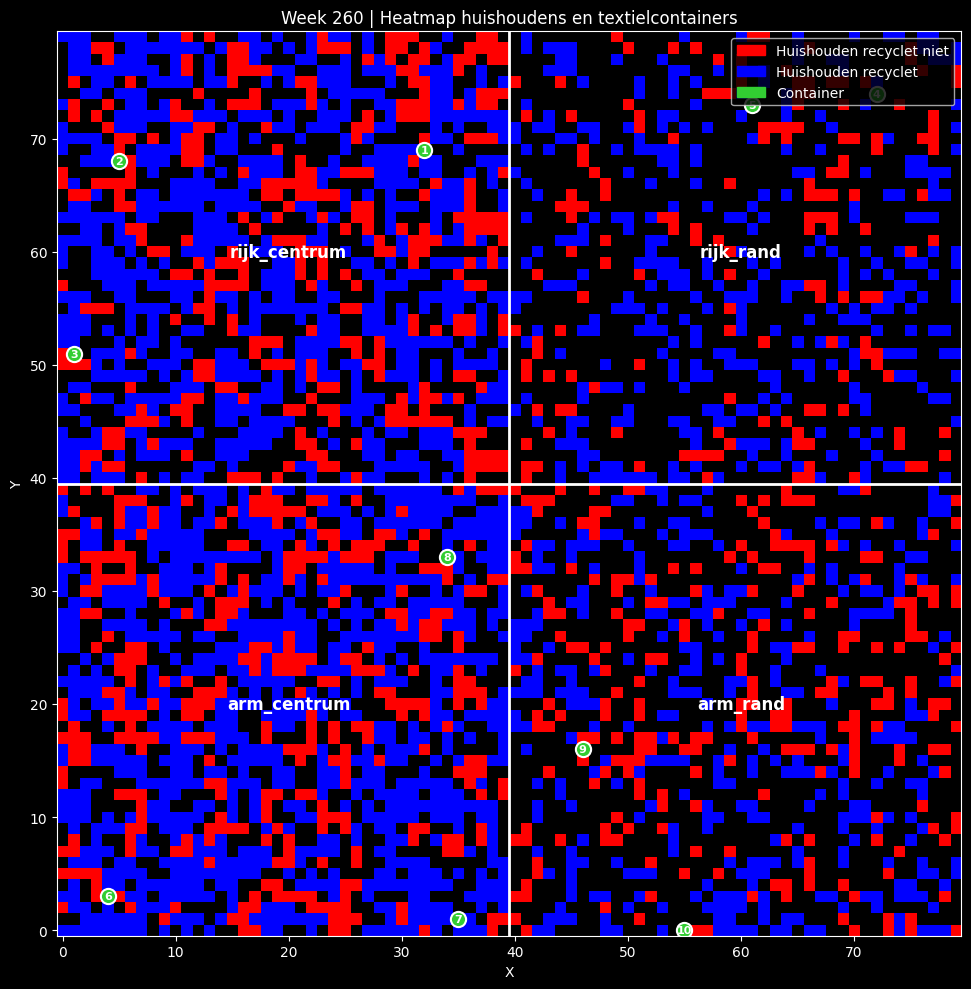

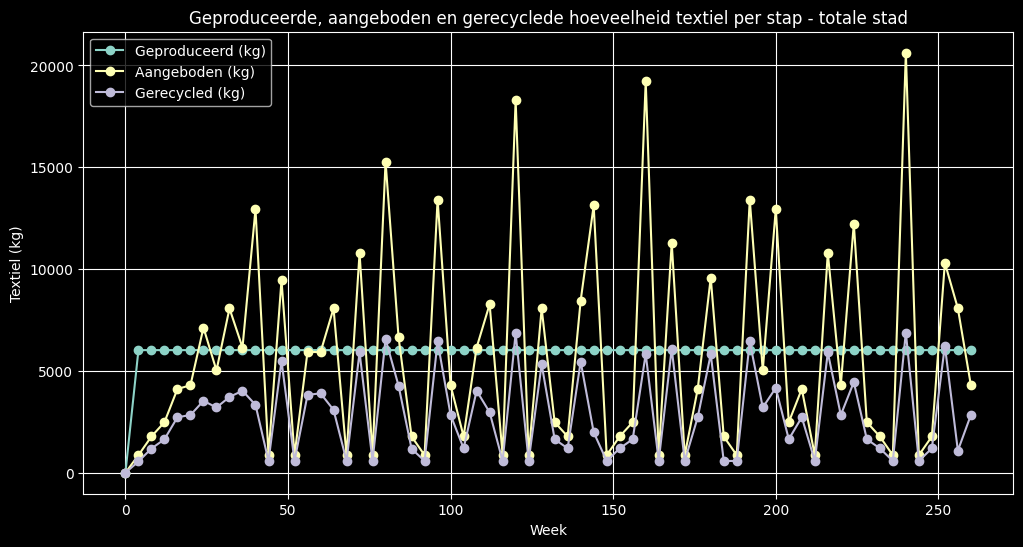

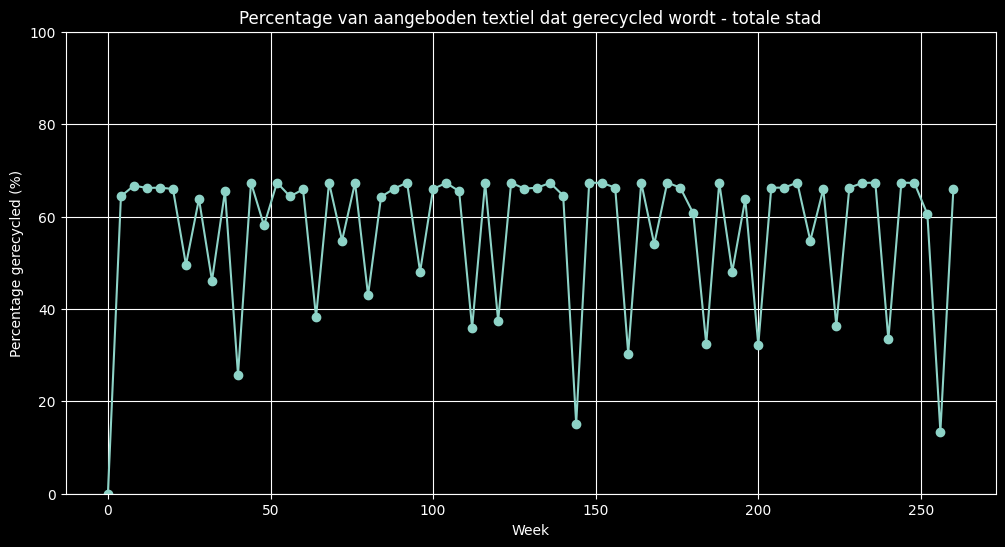

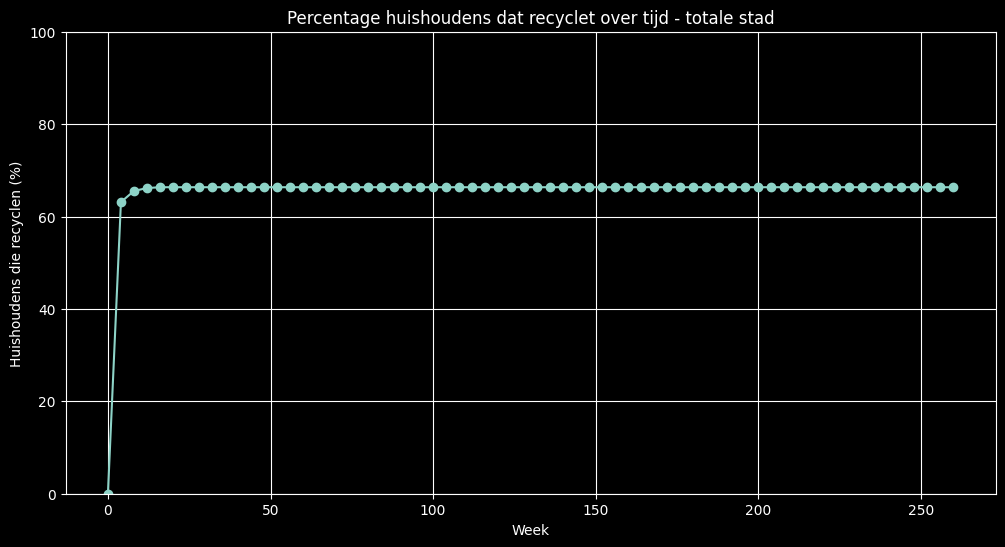

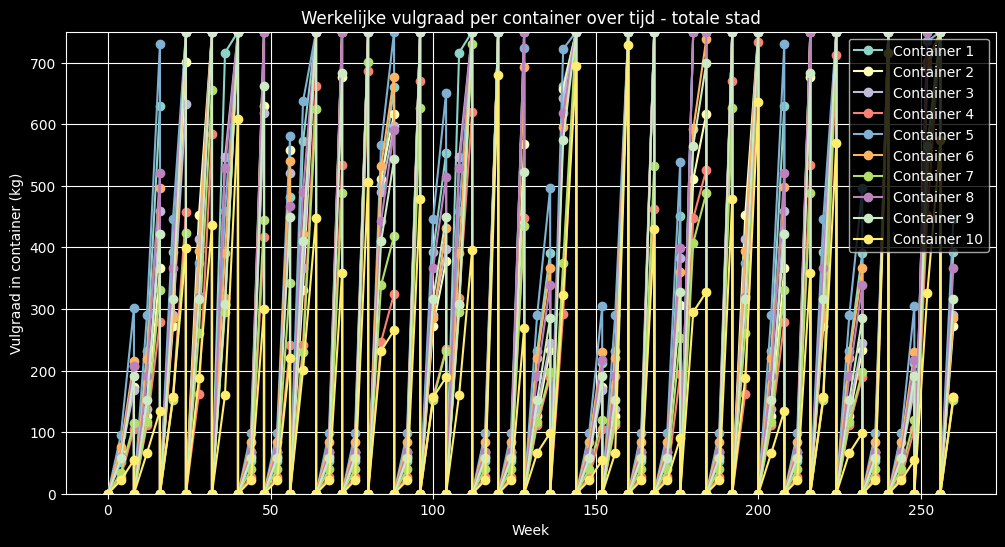

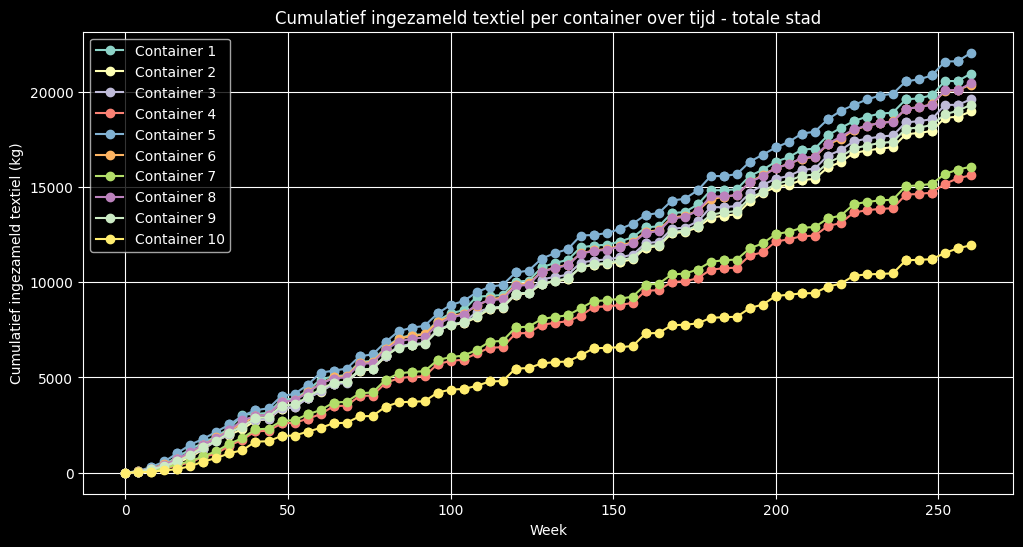

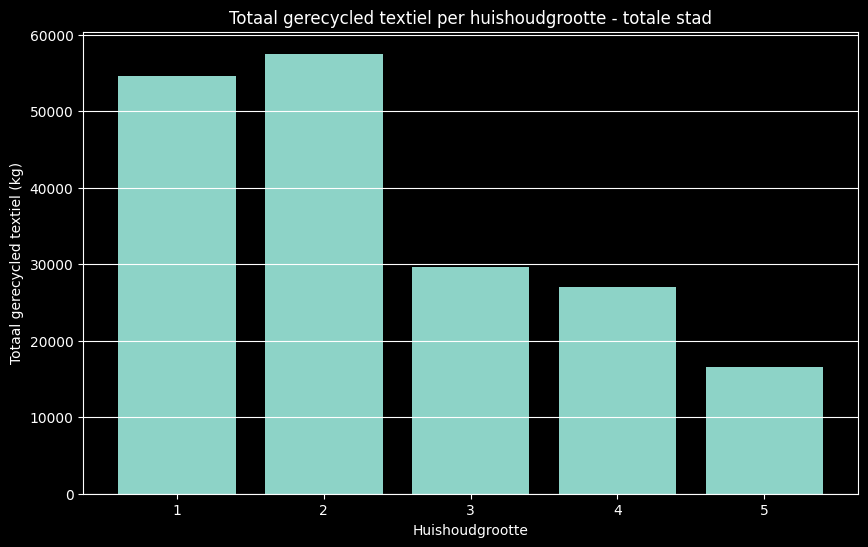

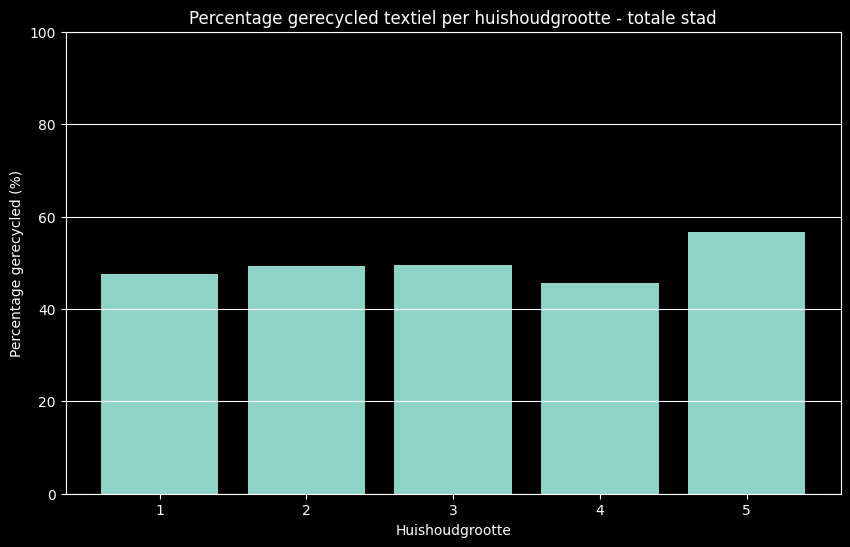

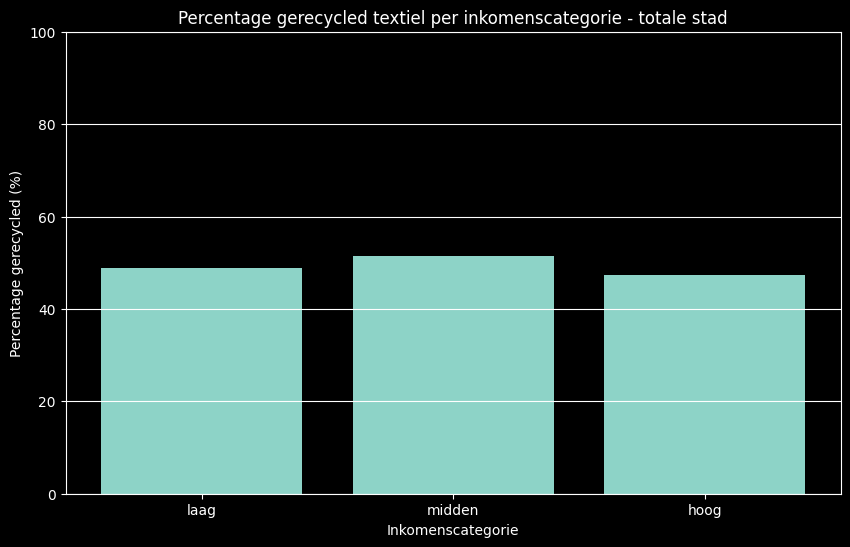

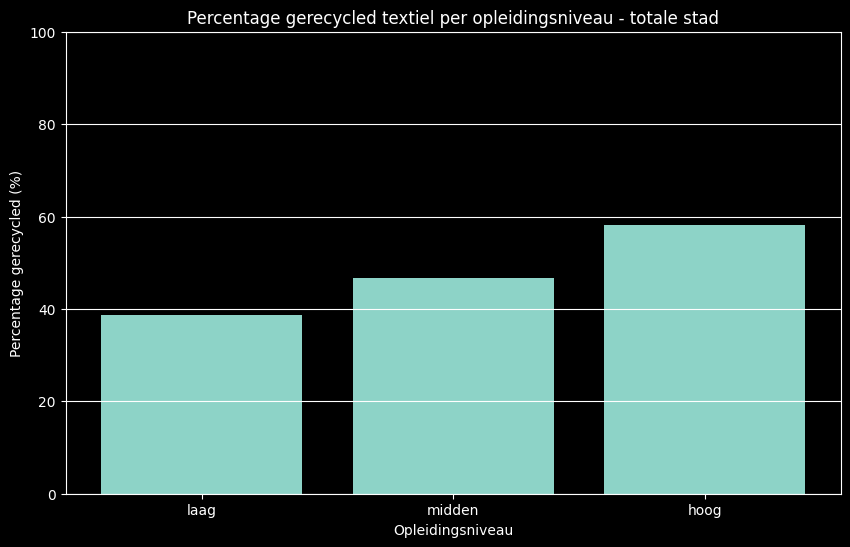

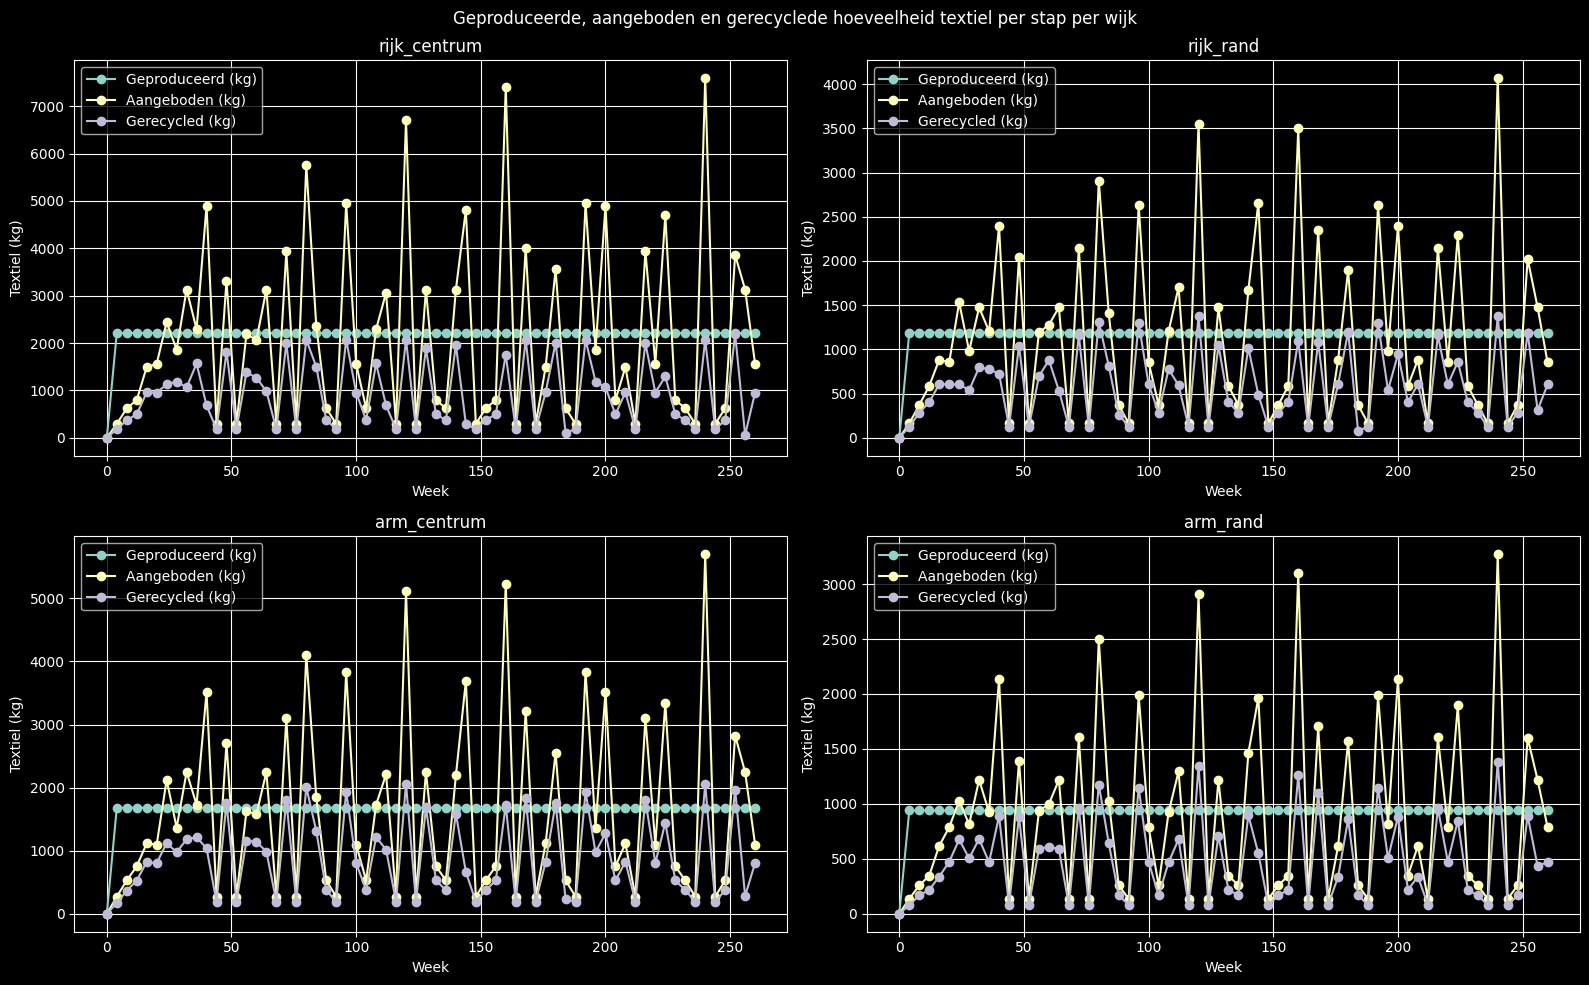

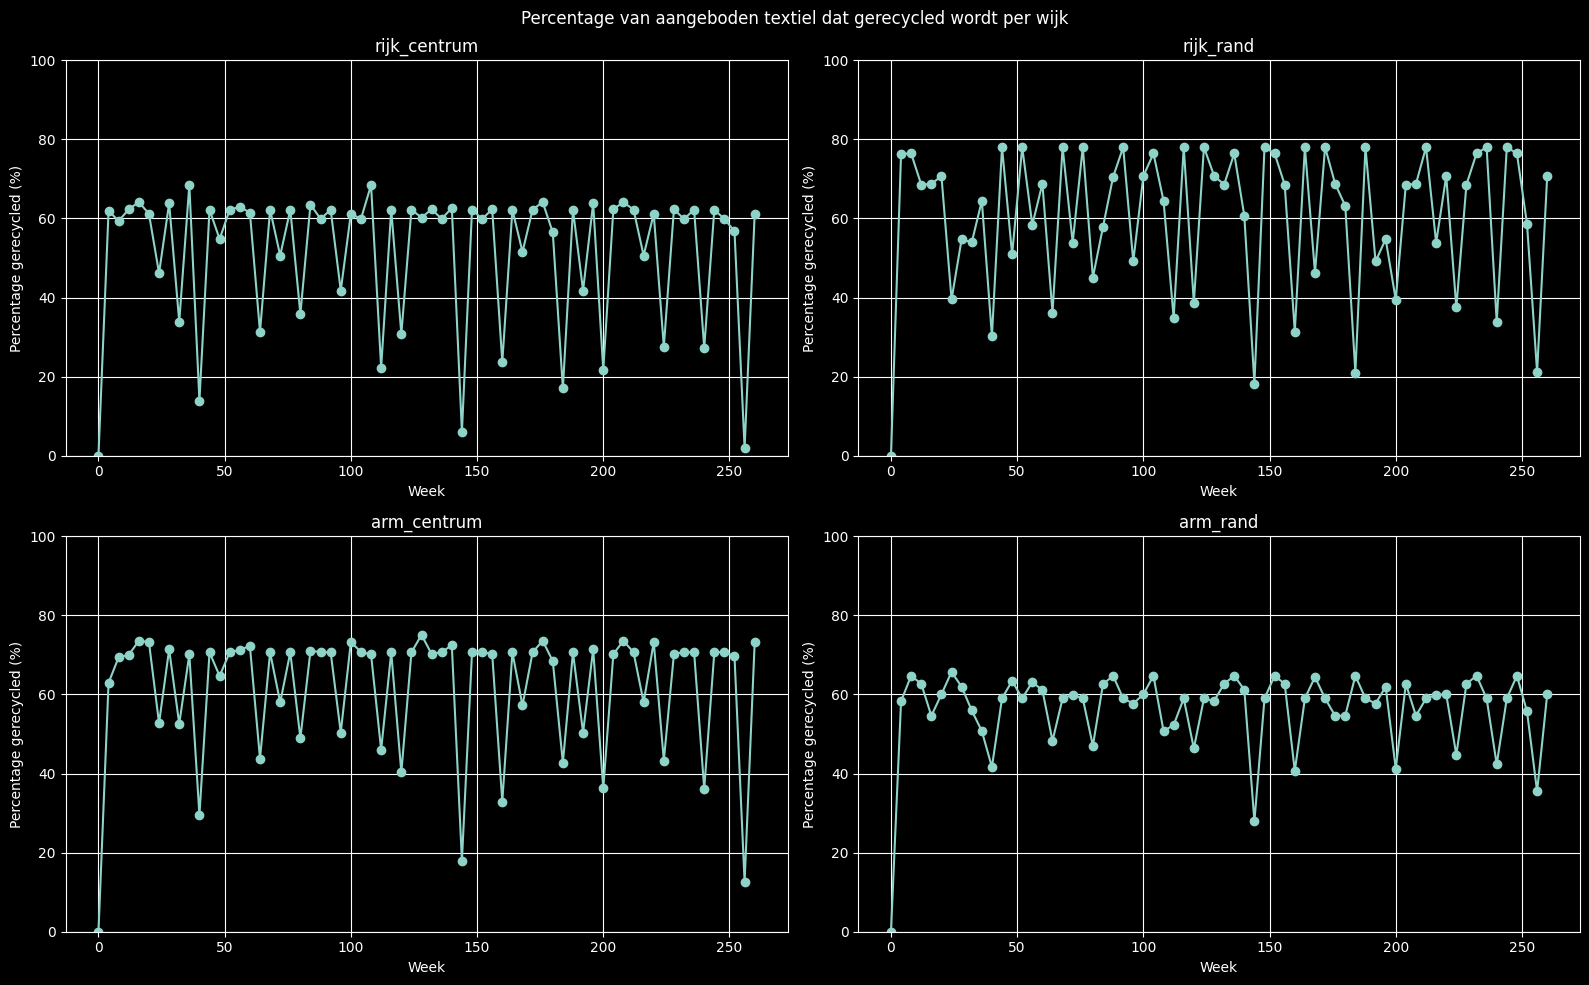

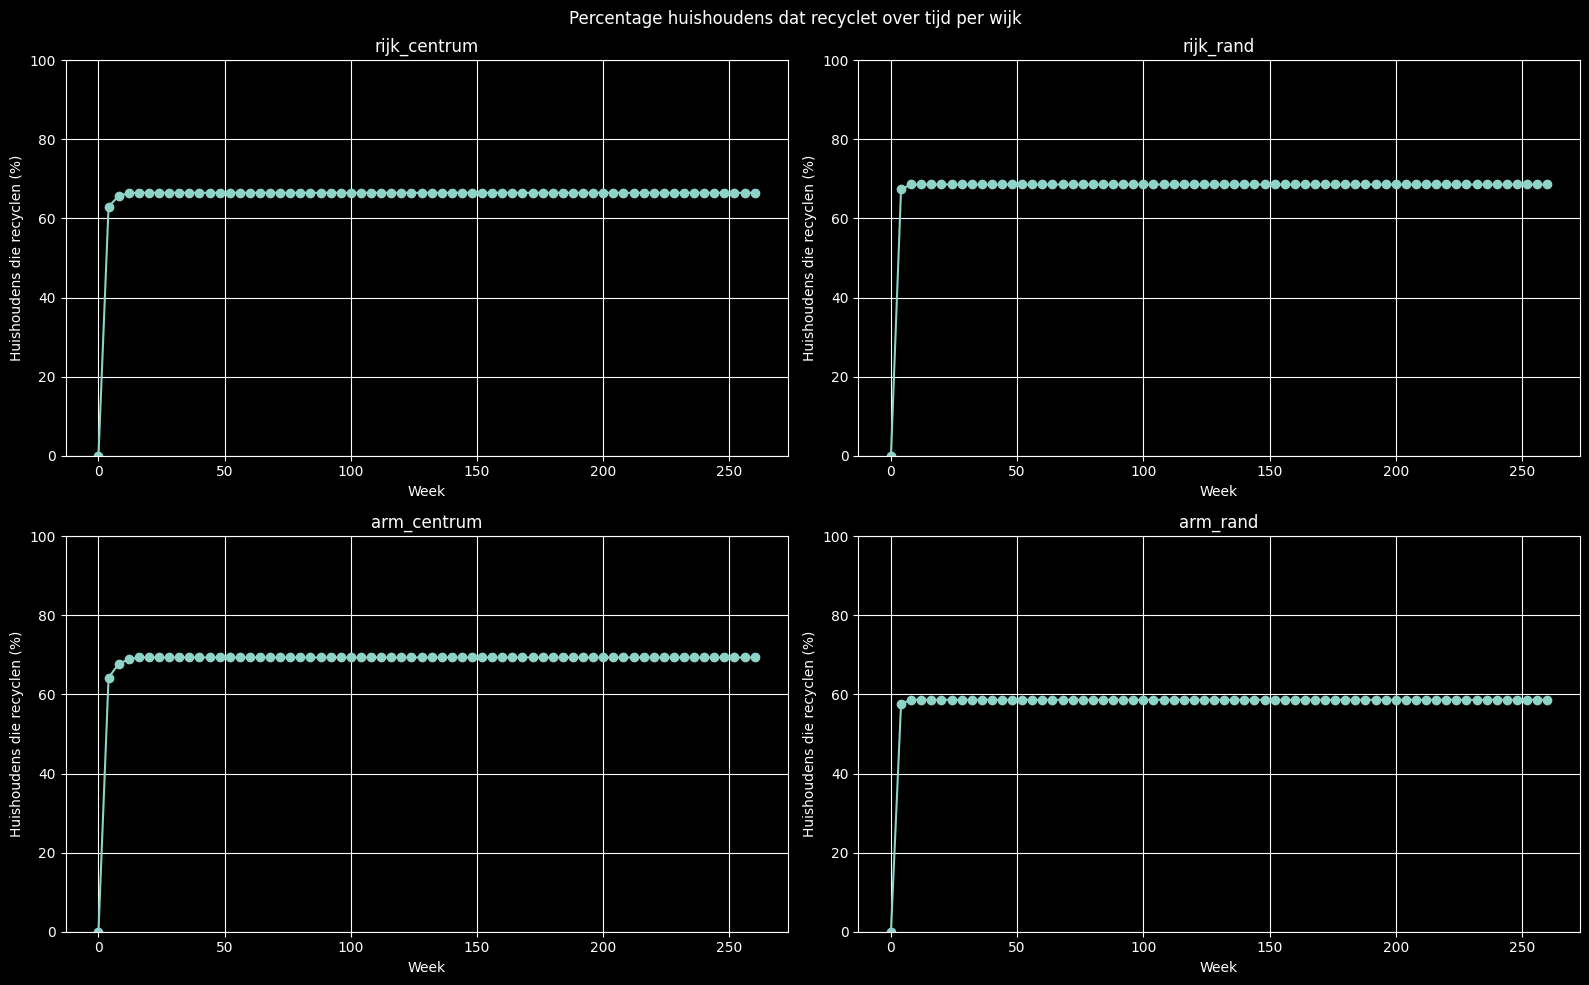

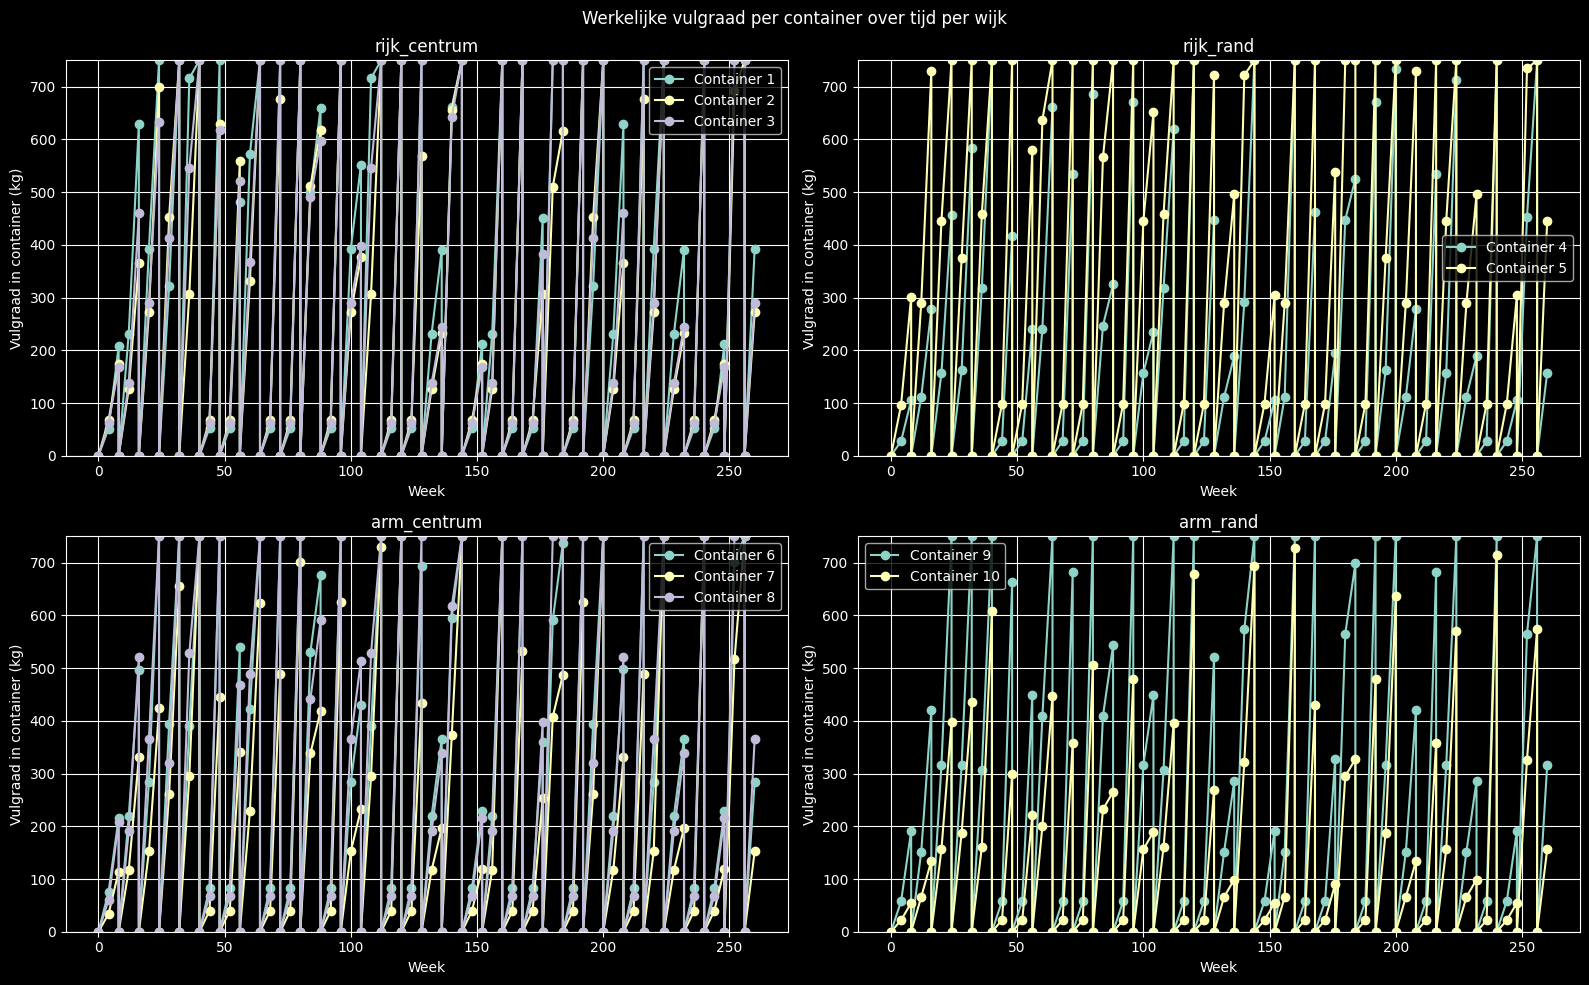

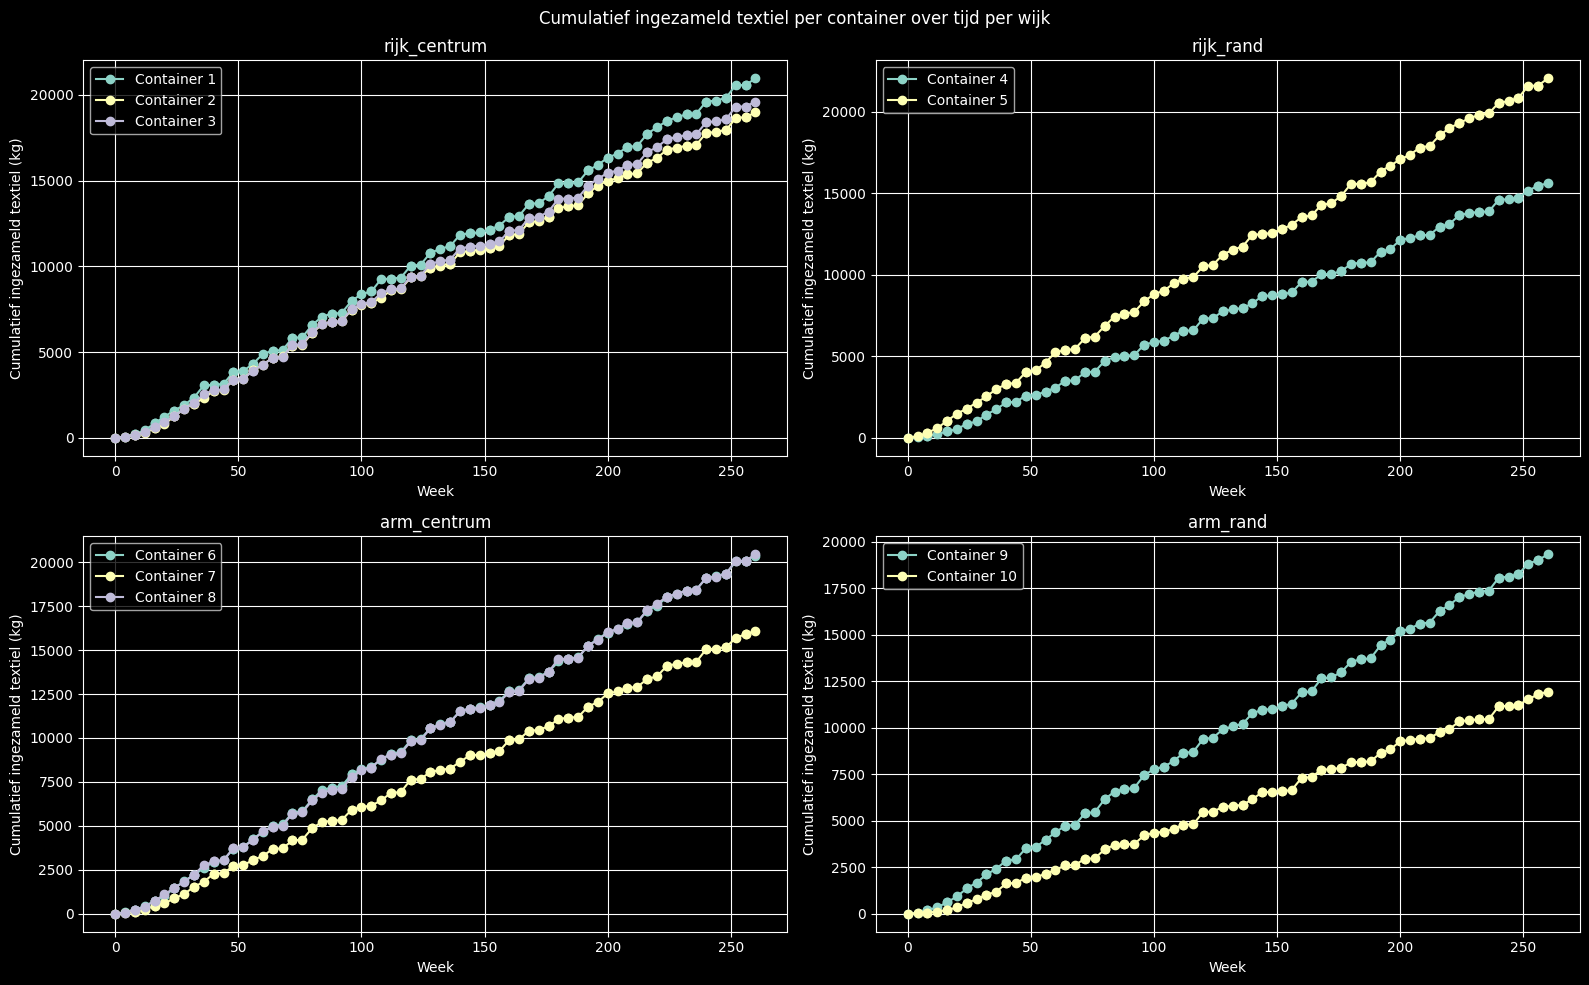


GEVOELIGHEIDSANALYSE - HOOFDTABEL
----------------------------------------------------------------------------------------------------
          variabele niveau  totaal_geproduceerd_kg  totaal_aangeboden_kg  totaal_gerecycled_kg  percentage_gerecycled  verschil_tov_basis  niet_gerecycled_door_capaciteit_kg
bevolkingsdichtheid   -20%                23922.76              10587.27               6771.94                  63.96               -2.12                                0.00
bevolkingsdichtheid  basis                30104.24              13529.61               8941.20                  66.09                0.00                                0.00
bevolkingsdichtheid   +20%                36432.46              16092.46              10871.21                  67.55                1.47                              120.67
            inkomen   -20%                28850.74              13043.85               8673.85                  66.50                0.41                               

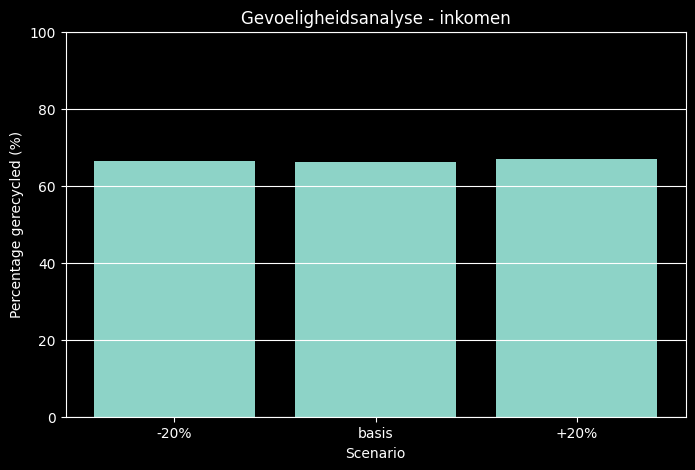

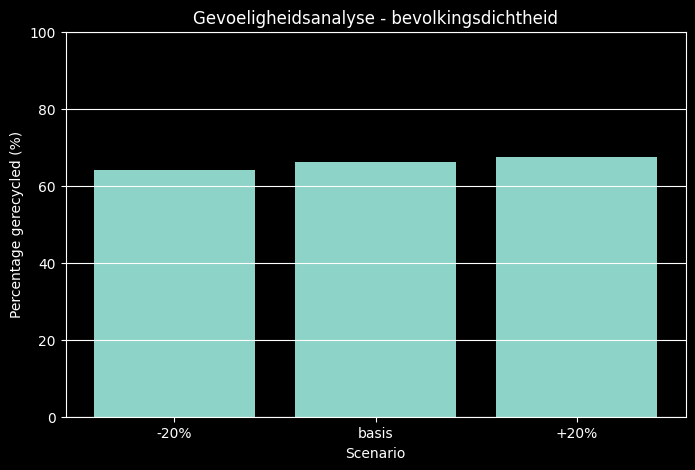

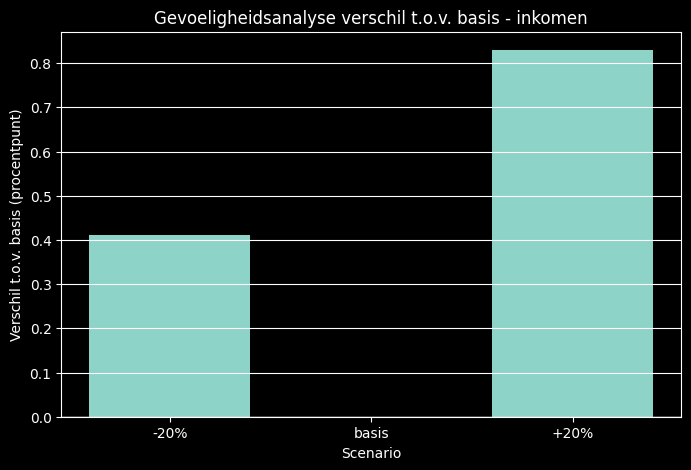

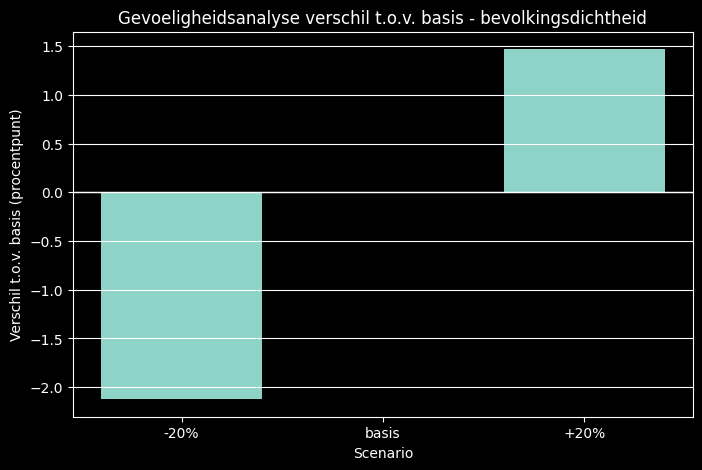

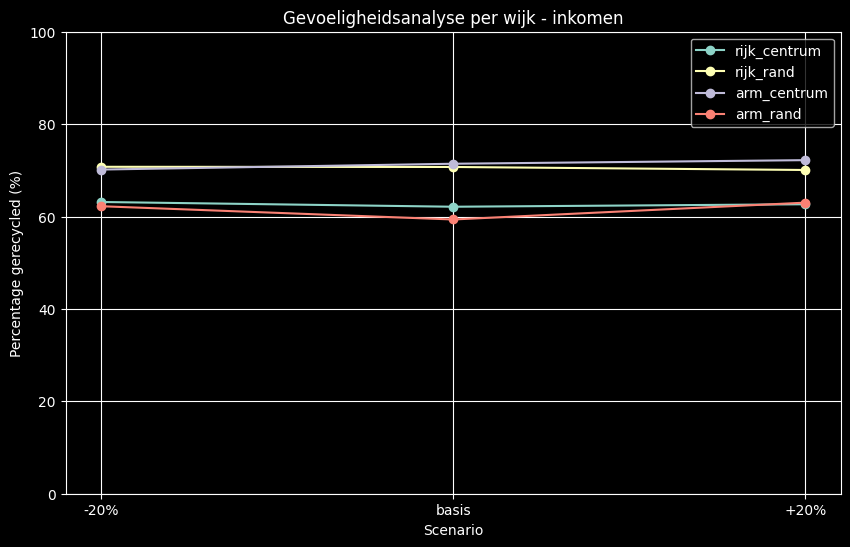

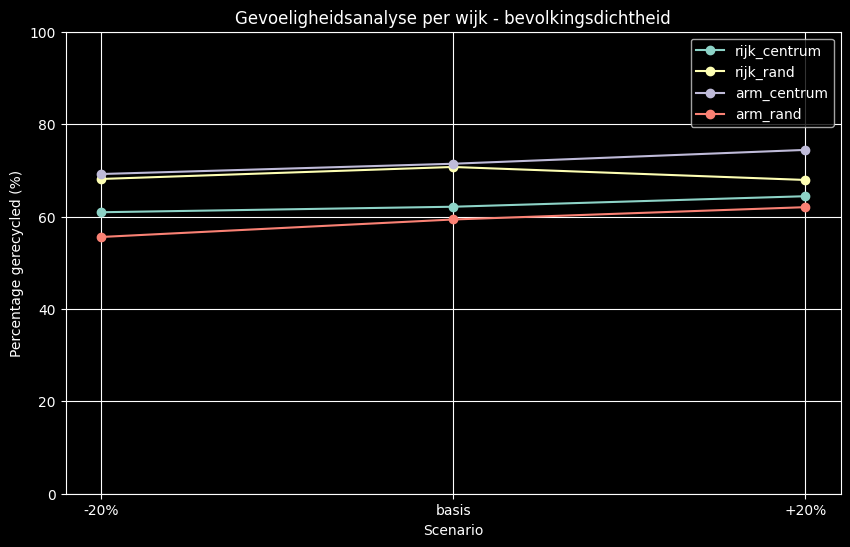

In [6]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mesa import Model, Agent
from mesa.space import MultiGrid


#dit is de eerste agent van het model, namelijk huishouden. Elk huishouden wat later wordt aangemaakt zal de eigenschappen van deze class krijgen.
class Huishouden(Agent):
#een huishouden: maakt textielafval, wordt beinvloed door buren, heeft een score voor recycling, brengt textiel naar de dichtsbijzijnde container


    def __init__(self, unique_id, model, wijk=None, wijk_inkomen_profiel=None, wijk_dichtheid=None):
        #dit zorgt ervoor dat voordat het model gaat runnen de agenten alvast een startwaarde krijgen
        super().__init__(unique_id, model)

        self.wijk = wijk
        self.wijk_inkomen_profiel = wijk_inkomen_profiel
        self.wijk_dichtheid = wijk_dichtheid

        # Basis recyclewaarde: elk huishouden krijgt een startscore voor hoe geneigd is om te recycelen
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15))) #trek een willekeurige waarde uit een verdeling met een waarde gemiddeld rond 0.5 met spreiding 0.15. De meeste huishoudens hebben dus een waarde rond 0.5 alleen een enkeling net wat lager of hoger. We willen een waarde tussen 0 en 1, daarvoor dient de (min(max)) functie.
        self.recyclewaarde = self.basis_recyclewaarde #zet de huidige recyclewaarde aan de basiswaarde gelijk (later wordt dit veranderd door bijvoobeeld buren, afstand of campanges)

        # Sociale invloed: op dit moment is er dus nog geen buurinvloed meegerekend
        self.sociale_gevoeligheid = 0

        # Gedrag: dit geeft de huishoudens een begin toestand. Op dit moment is het huishouden dus ingesteld op recyclet niet.
        self.recyclegedrag = False
        self.status = "recyclet_niet"

        # Opleidingsniveau: elk huishouden krijgt willekeurig een opleidingsniveau. Er kan gekozen worden tussen laag, midden en hoog. Hoevaak dit gebeurd hangt af van het gewicht dat aan deze status verbonden is.
        self.opleidingsniveau = self.model.random.choices(
            ["laag", "midden", "hoog"],
            weights=[0.262, 0.372, 0.366]
        )[0]

        # Inkomen wijkafhankelijk: als de wijk een rijke wijk is dan is daar 5% huishoudens met een laag inkomen, 35% met een middeninkomen en 60% met een hoog inkomen
        if self.wijk_inkomen_profiel == "hoog":
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.05, 0.35, 0.60]
            )[0]
        #als het een arme wijk is dan 45% huishoudens met een laag inkomen, 40% met een midden inkomen en 15% met een hoog inkomen
        elif self.wijk_inkomen_profiel == "laag":
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.45, 0.40, 0.15]
            )[0]
        #als een wijk geen profiel heeft gebruiken we een gemiddelde verdeling gebaseerd op het CBS
        else:
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.140, 0.556, 0.304]
            )[0]

        # Volgzaamheid richting overheidsbeleid/campagne: als een huishouden campanges belangrijk vindt dat luistert het naar camapnges. Bij neutraal maakt het wel of niet voeren van campanges niet uit en bij onbelangijk worden campanges genegeerd. In dit model zal 84,7% luisteren, 11.3% neutraal zijn en 4% niet luisteren.
        self.volgzaamheid_overheid = self.model.random.choices(
            ['belangrijk', 'neutraal', 'onbelangrijk'],
            weights=[0.847, 0.113, 0.04]
        )[0]

        # Huishoudgrootte: elk huishouden krijgt een groote toegewezen. hierin zijn de meeste huishoudens 1 persoons en zal dit geleidelijk afnemen, ook dit is gebaseerd op bronnen
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Textielafval: elk persoon in een huishouden maakt 0.23 kg afval per week. We rekenen per maand (ongeveer) dus 1 tijdstap moet 4 weken zijn
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Correctie afvalproductie op basis van inkomen: huishoudens met een laag inkomen zal minder afval maken dan een huishouden met een hoog inkomen. Ook dit is gebaseerd op bronnen. Hier is het belangrijkste inzicht dus dat rijkere mensen/huishoudens meer kopen en dus ook meer textiel zullen weggooien
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7

        #dit is de voorraad afval dat een huishouden thuis heeft, dit zal dus elke tijdstap optellen totdat ze het wegbrengen
        self.opgespaard_textielafval = 0

        # Weggooifrequentie: hoevaak gaat een huishouden naar de container. Gemiddeld gaat een huishouden elke 20 weken naar een textielbak, maar er is een variatie van 15 weken. De minimaal functie zorgt ervoor dat elk huishouden minimaal 4 weken wacht met weggooien en dat maximaal elke 40 weken textielafval bewaard word.
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Afstand: hier word in opgeslagen hoe ver de container weg is
        self.afstand = None

        # Totalen: hoeveel afval heeft dit huishouden ooit gemaakt en hoeveel is daarvan gerecyceld.
        self.totaal_opgeslagen = 0
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self): #deze functie gaat het recyclinggedrag opnieuw berekenen
        #begin niet opnieuw vanaf de vorige uitkomst, maar vanaf de oorspornkelijke recycle-neiging van dit huishouden
        self.recyclewaarde = self.basis_recyclewaarde

        # Buurinvloed: wat doen buren van dit huishouden. Sla op hoeveel buren er zijn en tel ze mee
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren
        self.recyclewaarde += buurinvloed # een positieve buurinvloed zal voor een hogere recyclewaarde zorgen. een negatieve buurinvloed voor een lagere waarde. Als je buren recycelen, gaat een huishouden ook eerder recycelen

        # Dichtstbijzijnde container: hoe ver is de container. Het intereseert mij niet welke container het is, maar ik wil wel de afstand kunnnen opslaan.
        _, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Afstandseffect: de maximale afstand kan de maximale grootte van het grid zijn. relatief gesproken is dicht bij 0 heel dichtbij en 1 is ver weg
        max_afstand = (self.model.grid.width - 1) + (self.model.grid.height - 1)
        rel_afstand = afstand / max_afstand if max_afstand > 0 else 0
        #hoe verder de container, hoe kleiner de kans dat een huishouden gaat recycelen
        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10

        # Inkomenseffect op gedrag: wat is het inkomen, hier zal een midden inkomen dus het meest gunstig zijn voor de recyclewaarde. mensen met een laag inkomen zullen iets minder snel recycelen. Mensen met een hoog inkomen zullen ook iets minder recycelen maar het beinvloed minder sterk
        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Opleidingsniveau-effect: wat is het opleidingsniveau. een hoog opgeleid huishouden zal voor een hogere recyclewaarde zorgen, midden opleiding voor een lagere recyclewaarde en laag opgeleid voor nog een sterkere daling. Hier verhoogt opleidingsniveau de kans op recycelen.
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.06
        elif self.opleidingsniveau == "midden":
            self.recyclewaarde -= 0.04
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.06
        #ik wil voorkomen dat de recyclewaarde boven 100% en onder 0% komt.
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Campagne-invloed: hoe gevoelig is dit huishouden voor campanges
        campagne_invloed = 0
        #hoe volgzamer je bent naar de overheid hoe meer effect de camapnge zal hebben op het huishouden
        if self.volgzaamheid_overheid == 'belangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.05
        elif self.volgzaamheid_overheid == 'neutraal':
            campagne_invloed = self.model.campagne_intensiteit * 0.03
        elif self.volgzaamheid_overheid == 'onbelangrijk':
            campagne_invloed = self.model.campagne_intensiteit * 0.01

        self.recyclewaarde += campagne_invloed
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempel: als de recyclewaarde hoog genoeg is, dan wordt het huishouden een recyler. boven de drempelwaarde zorgt voor recycelen, eronder word een huishouden niet gepusht.
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel
        self.status = "recyclet" if self.recyclegedrag else "recyclet_niet"

    def produceer_textiel(self): #elke stap is er meer textielafval van een huishouden
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap

        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap
        self.model.wijk_resultaten[self.wijk]["geproduceerd_deze_stap"] += self.textielafval_per_tijdstap

    #als het tijd is gaat een huishouden zijn kleding weggooien. dit registeren we voor het totaal en per wijk los.
    def probeer_textiel_weg_te_brengen(self):
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval

            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid
            self.model.wijk_resultaten[self.wijk]["aangeboden_deze_stap"] += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                #hoeveel plek is er nog
                ruimte_over = max(0, container.capaciteit - container.vulgraad)
                #wat in de container past gaat in de container
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)
                #wat niet in de container past wordt niet gerecyceld
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                container.vulgraad += hoeveelheid_te_recyclen
                container.totaal_ingezameld += hoeveelheid_te_recyclen

                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                self.model.wijk_resultaten[self.wijk]["gerecycled_deze_stap"] += hoeveelheid_te_recyclen
                self.model.wijk_resultaten[self.wijk][
                    "niet_gerecycled_door_capaciteit_deze_stap"] += hoeveelheid_niet_gerecycled_door_capaciteit

                # Per huishoudgrootte
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                # Per inkomen
                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                # Per opleidingsniveau
                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            else:
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            self.opgespaard_textielafval = 0
            self.weken_tot_weggooien = self.weggooifrequentie
#dus als er gerecyceld kan worden dan wordt er bijgehouden hoeveel er geryceled is, per wijk, per huishoudtype en wat er niet geryceld kon worden door een volle container. na het wegbrengen wordt het huishouden weer op 0 gezet en kan er opnieuw geteld worden.

#elke ronde wordt er afval gemaakt, gaat de tijd vooruit, veranderd het gedrag van een huishouden, wordt er geprobeerd textiel afval weg te brengen
    def step(self):
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()


# dit is een container waar textiel in gegooid kan worden
class Container(Agent):
    #elke container krijgt een uniek nummer zodat we ze later duidelijker in de grafiek kunnen zien, een maximale capaciteit, de vulgraad (begint op 0), hoeveel textiel erin is gegooid over tijd, en hoevaak hij geleegd word (elke 8 tijdstappen)
    def __init__(self, unique_id, model, container_nummer=None):
        super().__init__(unique_id, model)

        self.container_nummer = container_nummer
        self.capaciteit = 750
        self.vulgraad = 0
        self.totaal_ingezameld = 0
        self.ledigingsfrequentie = 8

    def ledigen(self): #de container is weer leeg
        self.vulgraad = 0


#dit is de stad waarin we werken. hierin staan huishoudens en containers
class Stad(Model):

    def __init__(self, width=80, height=80, campagne_intensiteit=1.0, seed=42):
        super().__init__()

        self.random.seed(seed)

        self.grid = MultiGrid(width, height, torus=False)
# in het model worden hierin alle huishoudens en containers bewaard
        self.huishoudens = []
        self.containers = []
#we starten bij week 0 met een drempelwaarde van 0.5 (dus wanneer gaat een huishouden dan wel recycelen), en hoeveel invloed een campange heeft
        self.id = 0
        self.week = 0
        self.drempel = 0.5
        self.campagne_intensiteit = campagne_intensiteit

        # Vier scenario-wijken: rijk centrum: hierin zijn huishoudens gemiddeld rijk, staan huishoudens dicht op elkaar want er zijn 1000 huishoudens en zijn er 3 containers aanwezig, dit werkt hetzelfde voor rijk rand, arm centrum en arm rand
        self.wijken = {
            "rijk_centrum": {
                "inkomen_profiel": "hoog",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1000,
                "aantal_containers": 3
            },
            "rijk_rand": {
                "inkomen_profiel": "hoog",
                "dichtheid": "laag",
                "aantal_huishoudens": 500,
                "aantal_containers": 2
            },
            "arm_centrum": {
                "inkomen_profiel": "laag",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1100,
                "aantal_containers": 3
            },
            "arm_rand": {
                "inkomen_profiel": "laag",
                "dichtheid": "laag",
                "aantal_huishoudens": 600,
                "aantal_containers": 2
            }
        }

        # Stapvariabelen: dit zijn de waarde voor 1 ronde. hier houd je dus bij hoeveel textiel gemaakt is, hoeveel aangeboden, hoeveel gerecyceld en hoeveel niet doordat een container vol zat
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Tijdsreeksen: hier sla je waarden op voor meerdere stappen achter elkaar. dit is vooral handig voor het maken van grafieken later.
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]

        # Container tijdas apart ivm lediging zichtbaar maken: zo kunnen we later zichtbaar maken hoe vol een container zit en wanneer ze precies geleegd worden
        self.geschiedenis_weken_containers = [0]
        self.geschiedenis_container_vulgraden = []
        self.geschiedenis_container_totaal_ingezameld = []

        # Wijkresultaten: voor elke wijk wordt bijgehouden hoeveel er is geproduceerd, aangeboden, gerecyceld, niet gerecyceld door capaciteit, percentages en containerdata
        self.wijk_resultaten = {}
        for wijknaam in self.wijken.keys():
            self.wijk_resultaten[wijknaam] = {
                "geproduceerd_deze_stap": 0,
                "aangeboden_deze_stap": 0,
                "gerecycled_deze_stap": 0,
                "niet_gerecycled_door_capaciteit_deze_stap": 0,
                "geproduceerd_per_stap": [0],
                "aangeboden_per_stap": [0],
                "gerecycled_per_stap": [0],
                "niet_gerecycled_door_capaciteit_per_stap": [0],
                "percentage_gerecycled_van_aangeboden_per_stap": [0],
                "percentage_huishoudens_dat_recyclet": [0],
                "container_vulgraden": [],
                "container_totaal_ingezameld": []
            }

        # Uitkomsten per categorie: we willen ook weten wat de verschillende type huishoudens doen. we houden dus alles bij voor huishoudgrootte, inkomen en opleidingsniveau
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        midden_x = width // 2
        midden_y = height // 2
#hier wordt de stad in 4 vlakken verdeeld.
        wijk_posities = {
            "rijk_centrum": [(x, y) for x in range(0, midden_x) for y in range(midden_y, height)],
            "rijk_rand": [(x, y) for x in range(midden_x, width) for y in range(midden_y, height)],
            "arm_centrum": [(x, y) for x in range(0, midden_x) for y in range(0, midden_y)],
            "arm_rand": [(x, y) for x in range(midden_x, width) for y in range(0, midden_y)],
        }
#per wijk kijken hoeveel huishoudens er moeten komen, hoeveel containers en waar ze geplaatst moeten worden
        for wijknaam, info in self.wijken.items():
            mogelijke_posities = wijk_posities[wijknaam][:]
            nodig = info["aantal_huishoudens"] + info["aantal_containers"]

#dit is een check zodat er niet meer mensen en containers neergezet kunnen worden dan dat er plek is
            if nodig > len(mogelijke_posities):
                raise ValueError(f"Te veel agents voor wijk {wijknaam}")

            gekozen_posities = self.random.sample(mogelijke_posities, nodig)
            container_posities = gekozen_posities[:info["aantal_containers"]]
            huishouden_posities = gekozen_posities[info["aantal_containers"]:]
#voor elke containerplek maken we een container, geven we het een nummer, koppelen we hem aan een specifieke wijk, zetten we hem op de grid, en voegen we hem toe aan de lijst van de containers
            for pos in container_posities:
                c = Container(self.next_id(), self, container_nummer=len(self.containers) + 1)
                c.wijk = wijknaam
                self.grid.place_agent(c, pos)
                self.containers.append(c)
#voor elk huishouden maken we een huishouden, koppelen we hem aan een wijk, geven we mee of het een arme of rijke wijk is en of het daar druk of rustig is, zetten we hem op de kaart en voegen we hem toe aan de lijst
            for pos in huishouden_posities:
                h = Huishouden(
                    self.next_id(),
                    self,
                    wijk=wijknaam,
                    wijk_inkomen_profiel=info["inkomen_profiel"],
                    wijk_dichtheid=info["dichtheid"]
                )
                self.grid.place_agent(h, pos)
                self.huishoudens.append(h)
#nadat alles gemaakt is berekenen we of een huishouden gaat recycelen of niet. dit vormt de eerste status van een huishouden
        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden containerhistorie: aan het begin zijn containers nog leeg, maar we slaan alvast waarde op zodat alle grafieken later mooi gaan lopen
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])

        for wijknaam in self.wijken.keys():
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            self.wijk_resultaten[wijknaam]["container_vulgraden"].append(
                [container.vulgraad for container in wijk_containers]
            )
            self.wijk_resultaten[wijknaam]["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers]
            )

    def next_id(self):
        self.id += 1
        return self.id
# dit berekent de afstand voor twee dingen op de grid, hoeveel stapjes omlaag/omhoog of opzij
    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
#zoek voor een bepaald huishouden wat de meest dichtsbijzijnde container is
    def dichtstbijzijnde_container(self, huishouden):
        #kijk naar containers in de eigen wijk
        containers_in_eigen_wijk = [c for c in self.containers if c.wijk == huishouden.wijk]
        #als dit niet gaat kijk dan naar de andere containers
        te_controleren_containers = containers_in_eigen_wijk if containers_in_eigen_wijk else self.containers

        beste_container = None
        kleinste_afstand = float("inf")
#ga door alle containers heen en kijk of een huishouden nog een kortere afstand kan hebben tot een container
        for container in te_controleren_containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)
            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container
#welke container is het beste en wat is de afstand daarvoor
        return beste_container, kleinste_afstand
#wat doen directe buren van dit huishouden en hoe beinvloed dit het eigen gedrag
    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0
#kijk enkel naar de vier directe buren
        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)]) #kijk wat een buur heeft: een huishouden, een container of niks?

                for agent in inhoud:
                    if isinstance(agent, Huishouden) and agent.wijk == huishouden.wijk: #alleen als het een huishouden is en de buur in dezelfde wijk zit
                        aantal_buren += 1
                        buurinvloed += 0.05 if agent.recyclegedrag else -0.05 #als een buur recycelt al die invloed positief zijn op het huishouden, anders negatief
#geef terug hoeveel buren er zijn en wat de sociale invloed daarvan is op het huishouden
        return aantal_buren, buurinvloed
#sla alles op, dit kan je zien als een soort boekhouding
    def verzamel_resultaten(self):
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)
#van alles wat aangeboden is door huishoudens, hoeveel is daarvan ook echt daadwerkelijk gerecyceld
        percentage = (
                             self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100 if self.aangeboden_deze_stap > 0 else 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag) #tel hoeveel huishoudens recycelen
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100 if self.huishoudens else 0
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)
#sla op hoe vol een container nu is, hoeveel elke container heeft ingezameld. ook dit is eigenlijk voor grafieken.
        self.geschiedenis_weken_containers.append(self.week)
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])
#zet deze stappen voor elke wijk
        for wijknaam in self.wijken.keys():
            wijk_data = self.wijk_resultaten[wijknaam]

            wijk_data["geproduceerd_per_stap"].append(wijk_data["geproduceerd_deze_stap"])
            wijk_data["aangeboden_per_stap"].append(wijk_data["aangeboden_deze_stap"])
            wijk_data["gerecycled_per_stap"].append(wijk_data["gerecycled_deze_stap"])
            wijk_data["niet_gerecycled_door_capaciteit_per_stap"].append(
                wijk_data["niet_gerecycled_door_capaciteit_deze_stap"])

            percentage_wijk = (
                (wijk_data["gerecycled_deze_stap"] / wijk_data["aangeboden_deze_stap"]) * 100
                if wijk_data["aangeboden_deze_stap"] > 0 else 0
            )
            wijk_data["percentage_gerecycled_van_aangeboden_per_stap"].append(percentage_wijk)

            wijk_huishoudens = [h for h in self.huishoudens if h.wijk == wijknaam]
            aantal_recyclers_wijk = sum(1 for h in wijk_huishoudens if h.recyclegedrag)
            percentage_recyclers_wijk = (aantal_recyclers_wijk / len(wijk_huishoudens)) * 100 if wijk_huishoudens else 0
            wijk_data["percentage_huishoudens_dat_recyclet"].append(percentage_recyclers_wijk)

            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            wijk_data["container_vulgraden"].append([container.vulgraad for container in wijk_containers])
            wijk_data["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers])
#als een container tussendoor geleegd word willen we dit zichtbaar maken in een grafiek. dus dan slaan we opnieuw op voor die week wat de vulgraad is, hoeveel er totaal is ingezemald en dat dan weer per wijk
    def registreer_lediging_in_containergrafieken(self):
        self.geschiedenis_weken_containers.append(self.week)
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])

        for wijknaam in self.wijken.keys():
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            self.wijk_resultaten[wijknaam]["container_vulgraden"].append(
                [container.vulgraad for container in wijk_containers]
            )
            self.wijk_resultaten[wijknaam]["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers]
            )
# dit is eigenlijk een gehele rond in de stad. er gaan telkens 4 weken voorbij elk huishouden doet iets en de containers worden eventueel geleegd
    def step(self):
        self.week += 4
#alle maandtellers worden weer op 0 gezet
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        for wijknaam in self.wijken.keys():
            self.wijk_resultaten[wijknaam]["geproduceerd_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["aangeboden_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["gerecycled_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["niet_gerecycled_door_capaciteit_deze_stap"] = 0
#elk huishouden gaat textiel produceren, tijd aftellen totdat ze textiel gaan wegbrengen, gedrag veranderen
        for huishouden in self.huishoudens:
            huishouden.step()

        self.verzamel_resultaten()
#als er containers zijn en het is tijd om ze te legen, doe dat dan
        if self.containers and self.week % self.containers[0].ledigingsfrequentie == 0:
            for container in self.containers:
                container.ledigen()
            self.registreer_lediging_in_containergrafieken()


    def visualiseer_heatmap(self):
        #maak een kaart aan voor de stad
        heatmap = np.zeros((self.grid.height, self.grid.width))
# geef elk huishouden een code of ze wel of niet recycelen
        for h in self.huishoudens:
            x, y = h.pos
            heatmap[y, x] = 2 if h.recyclegedrag else 1
#geef containers code 3
        for c in self.containers:
            x, y = c.pos
            heatmap[y, x] = 3
#elke code staat voor een kleur
        cmap = ListedColormap(["black", "red", "blue", "limegreen"])

        plt.figure(figsize=(10, 10))
        plt.imshow(heatmap, origin="lower", cmap=cmap, interpolation="nearest")
        plt.title(f"Week {self.week} | Heatmap huishoudens en textielcontainers")
        plt.xlabel("X")
        plt.ylabel("Y")

        midden_x = self.grid.width // 2
        midden_y = self.grid.height // 2
#zorg ervoor dat je de wijken visueel ook echt scheidt
        plt.axvline(midden_x - 0.5, color="white", linewidth=2)
        plt.axhline(midden_y - 0.5, color="white", linewidth=2)

        plt.text(midden_x / 2, midden_y + (self.grid.height - midden_y) / 2, "rijk_centrum",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x + (self.grid.width - midden_x) / 2, midden_y + (self.grid.height - midden_y) / 2, "rijk_rand",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x / 2, midden_y / 2, "arm_centrum",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x + (self.grid.width - midden_x) / 2, midden_y / 2, "arm_rand",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")

        # Vaste containernummers tonen op de heatmap
        for c in self.containers:
            x, y = c.pos

            plt.scatter(x, y, s=120, c="limegreen", edgecolors="white", linewidths=1.5)
#geef elke container ook het nummer op de kaart, dit is makkelijker voor conclusies trekken later
            plt.text(
                x, y, str(c.container_nummer),
                color="white",
                ha="center",
                va="center",
                fontsize=8,
                weight="bold"
            )

        import matplotlib.patches as mpatches
        legend_items = [
            mpatches.Patch(color="red", label="Huishouden recyclet niet"),
            mpatches.Patch(color="blue", label="Huishouden recyclet"),
            mpatches.Patch(color="limegreen", label="Container")
        ]
        plt.legend(handles=legend_items, loc="upper right")
        plt.tight_layout()
        plt.show()
#deze map laat zien waar huishoudens wonen, wie receycelt, en waar containers staan

    def plot_totale_kg_opgeslagen_vs_gerecycled(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.geproduceerd_per_stap, marker="o", label="Geproduceerd (kg)")
        plt.plot(self.geschiedenis_weken, self.aangeboden_per_stap, marker="o", label="Aangeboden (kg)")
        plt.plot(self.geschiedenis_weken, self.gerecycled_per_stap, marker="o", label="Gerecycled (kg)")
        plt.xlabel("Week")
        plt.ylabel("Textiel (kg)")
        plt.title("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap - totale stad")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_percentage_gerecycled_over_tijd(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_gerecycled_van_aangeboden_per_stap, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage van aangeboden textiel dat gerecycled wordt - totale stad")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_percentage_huishoudens_dat_recyclet(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.geschiedenis_weken, self.percentage_huishoudens_dat_recyclet, marker="o")
        plt.xlabel("Week")
        plt.ylabel("Huishoudens die recyclen (%)")
        plt.title("Percentage huishoudens dat recyclet over tijd - totale stad")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.show()

    def plot_container_vulgraden(self):
        plt.figure(figsize=(12, 6))
        for i, container in enumerate(self.containers):
            vulgraden_i = [stap[i] for stap in self.geschiedenis_container_vulgraden]
            plt.plot(
                self.geschiedenis_weken_containers,
                vulgraden_i,
                marker="o",
                label=f"Container {container.container_nummer}"
            )
        plt.xlabel("Week")
        plt.ylabel("Vulgraad in container (kg)")
        plt.title("Werkelijke vulgraad per container over tijd - totale stad")
        plt.ylim(0, 750)
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_container_cumulatief_ingezameld(self):
        plt.figure(figsize=(12, 6))
        for i, container in enumerate(self.containers):
            cumulatief_i = [stap[i] for stap in self.geschiedenis_container_totaal_ingezameld]
            plt.plot(
                self.geschiedenis_weken_containers,
                cumulatief_i,
                marker="o",
                label=f"Container {container.container_nummer}"
            )
        plt.xlabel("Week")
        plt.ylabel("Cumulatief ingezameld textiel (kg)")
        plt.title("Cumulatief ingezameld textiel per container over tijd - totale stad")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gerecycled_per_huishoudgrootte(self):
        groottes = list(self.gerecycled_per_huishoudgrootte.keys())
        waarden = list(self.gerecycled_per_huishoudgrootte.values())

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, waarden)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Totaal gerecycled textiel (kg)")
        plt.title("Totaal gerecycled textiel per huishoudgrootte - totale stad")
        plt.xticks(groottes)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_huishoudgrootte(self):
        groottes = [1, 2, 3, 4, 5]
        percentages = []

        for grootte in groottes:
            aangeboden = self.aangeboden_per_huishoudgrootte[grootte]
            gerecycled = self.gerecycled_per_huishoudgrootte[grootte]
            percentages.append((gerecycled / aangeboden) * 100 if aangeboden > 0 else 0)

        plt.figure(figsize=(10, 6))
        plt.bar(groottes, percentages)
        plt.xlabel("Huishoudgrootte")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per huishoudgrootte - totale stad")
        plt.xticks(groottes)
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_inkomen(self):
        inkomens = ["laag", "midden", "hoog"]
        percentages = []

        for inkomen in inkomens:
            aangeboden = self.aangeboden_per_huishoudinkomen[inkomen]
            gerecycled = self.gerecycled_per_huishoudinkomen[inkomen]
            percentages.append((gerecycled / aangeboden) * 100 if aangeboden > 0 else 0)

        plt.figure(figsize=(10, 6))
        plt.bar(inkomens, percentages)
        plt.xlabel("Inkomenscategorie")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per inkomenscategorie - totale stad")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    def plot_percentage_gerecycled_per_opleidingsniveau(self):
        niveaus = ["laag", "midden", "hoog"]
        percentages = []

        for niveau in niveaus:
            aangeboden = self.aangeboden_per_opleidingsniveau[niveau]
            gerecycled = self.gerecycled_per_opleidingsniveau[niveau]
            percentages.append((gerecycled / aangeboden) * 100 if aangeboden > 0 else 0)

        plt.figure(figsize=(10, 6))
        plt.bar(niveaus, percentages)
        plt.xlabel("Opleidingsniveau")
        plt.ylabel("Percentage gerecycled (%)")
        plt.title("Percentage gerecycled textiel per opleidingsniveau - totale stad")
        plt.ylim(0, 100)
        plt.grid(True, axis="y")
        plt.show()

    # ========================================================
    # WIJKGRAFIEKEN
    # ========================================================
    def plot_wijk_totale_kg_opgeslagen_vs_gerecycled(self):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for ax, wijknaam in zip(axes, self.wijken.keys()):
            data = self.wijk_resultaten[wijknaam]
            ax.plot(self.geschiedenis_weken, data["geproduceerd_per_stap"], marker="o", label="Geproduceerd (kg)")
            ax.plot(self.geschiedenis_weken, data["aangeboden_per_stap"], marker="o", label="Aangeboden (kg)")
            ax.plot(self.geschiedenis_weken, data["gerecycled_per_stap"], marker="o", label="Gerecycled (kg)")
            ax.set_title(wijknaam)
            ax.set_xlabel("Week")
            ax.set_ylabel("Textiel (kg)")
            ax.grid(True)
            ax.legend()

        plt.suptitle("Geproduceerde, aangeboden en gerecyclede hoeveelheid textiel per stap per wijk")
        plt.tight_layout()
        plt.show()

    def plot_wijk_percentage_gerecycled_over_tijd(self):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for ax, wijknaam in zip(axes, self.wijken.keys()):
            data = self.wijk_resultaten[wijknaam]
            ax.plot(self.geschiedenis_weken, data["percentage_gerecycled_van_aangeboden_per_stap"], marker="o")
            ax.set_title(wijknaam)
            ax.set_xlabel("Week")
            ax.set_ylabel("Percentage gerecycled (%)")
            ax.set_ylim(0, 100)
            ax.grid(True)

        plt.suptitle("Percentage van aangeboden textiel dat gerecycled wordt per wijk")
        plt.tight_layout()
        plt.show()

    def plot_wijk_percentage_huishoudens_dat_recyclet(self):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for ax, wijknaam in zip(axes, self.wijken.keys()):
            data = self.wijk_resultaten[wijknaam]
            ax.plot(self.geschiedenis_weken, data["percentage_huishoudens_dat_recyclet"], marker="o")
            ax.set_title(wijknaam)
            ax.set_xlabel("Week")
            ax.set_ylabel("Huishoudens die recyclen (%)")
            ax.set_ylim(0, 100)
            ax.grid(True)

        plt.suptitle("Percentage huishoudens dat recyclet over tijd per wijk")
        plt.tight_layout()
        plt.show()

    def plot_wijk_container_vulgraden(self):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for ax, wijknaam in zip(axes, self.wijken.keys()):
            data = self.wijk_resultaten[wijknaam]
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]

            for i, container in enumerate(wijk_containers):
                vulgraden_i = [stap[i] for stap in data["container_vulgraden"]]
                ax.plot(
                    self.geschiedenis_weken_containers,
                    vulgraden_i,
                    marker="o",
                    label=f"Container {container.container_nummer}"
                )

            ax.set_title(wijknaam)
            ax.set_xlabel("Week")
            ax.set_ylabel("Vulgraad in container (kg)")
            ax.set_ylim(0, 750)
            ax.grid(True)
            ax.legend()

        plt.suptitle("Werkelijke vulgraad per container over tijd per wijk")
        plt.tight_layout()
        plt.show()

    def plot_wijk_container_cumulatief_ingezameld(self):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.flatten()

        for ax, wijknaam in zip(axes, self.wijken.keys()):
            data = self.wijk_resultaten[wijknaam]
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]

            for i, container in enumerate(wijk_containers):
                cumulatief_i = [stap[i] for stap in data["container_totaal_ingezameld"]]
                ax.plot(
                    self.geschiedenis_weken_containers,
                    cumulatief_i,
                    marker="o",
                    label=f"Container {container.container_nummer}"
                )

            ax.set_title(wijknaam)
            ax.set_xlabel("Week")
            ax.set_ylabel("Cumulatief ingezameld textiel (kg)")
            ax.grid(True)
            ax.legend()

        plt.suptitle("Cumulatief ingezameld textiel per container over tijd per wijk")
        plt.tight_layout()
        plt.show()


# ============================================================
# GEVOELIGHEIDSANALYSE
# ============================================================
def normaliseer_gewichten(gewichten):
    totaal = sum(gewichten)
    return [g / totaal for g in gewichten]


def aangepaste_inkomensgewichten(profiel, factor):
    """
    factor = -0.20, 0.0, +0.20
    """
    if profiel == "hoog":
        gewichten = [
            0.05 * (1 - factor),
            0.35,
            0.60 * (1 + factor)
        ]
    elif profiel == "laag":
        gewichten = [
            0.45 * (1 - factor),
            0.40,
            0.15 * (1 + factor)
        ]
    else:
        gewichten = [
            0.140 * (1 - factor),
            0.556,
            0.304 * (1 + factor)
        ]

    gewichten = [max(0.0001, g) for g in gewichten]
    return normaliseer_gewichten(gewichten)


def herbereken_textielafval_op_basis_van_inkomen(huishouden):
    basis = 0.23 * huishouden.huishoudgrootte * 4

    if huishouden.inkomen == "laag":
        huishouden.textielafval_per_tijdstap = basis * 0.6
    elif huishouden.inkomen == "midden":
        huishouden.textielafval_per_tijdstap = basis * 1.0
    elif huishouden.inkomen == "hoog":
        huishouden.textielafval_per_tijdstap = basis * 1.7


def pas_inkomen_aan(model, factor):
    for h in model.huishoudens:
        gewichten = aangepaste_inkomensgewichten(h.wijk_inkomen_profiel, factor)
        h.inkomen = model.random.choices(
            ["laag", "midden", "hoog"],
            weights=gewichten
        )[0]
        herbereken_textielafval_op_basis_van_inkomen(h)

    for h in model.huishoudens:
        h.update_recyclegedrag()


def wijk_posities_van_model(model):
    midden_x = model.grid.width // 2
    midden_y = model.grid.height // 2

    return {
        "rijk_centrum": [(x, y) for x in range(0, midden_x) for y in range(midden_y, model.grid.height)],
        "rijk_rand": [(x, y) for x in range(midden_x, model.grid.width) for y in range(midden_y, model.grid.height)],
        "arm_centrum": [(x, y) for x in range(0, midden_x) for y in range(0, midden_y)],
        "arm_rand": [(x, y) for x in range(midden_x, model.grid.width) for y in range(0, midden_y)],
    }


def vrije_posities_in_wijk(model, wijknaam):
    vrije = []
    alle_posities = wijk_posities_van_model(model)[wijknaam]

    for pos in alle_posities:
        inhoud = model.grid.get_cell_list_contents([pos])
        if len(inhoud) == 0:
            vrije.append(pos)

    return vrije


def pas_bevolkingsdichtheid_aan(model, factor):
    basis_aantallen = {
        wijknaam: info["aantal_huishoudens"]
        for wijknaam, info in model.wijken.items()
    }

    for wijknaam, basis in basis_aantallen.items():
        doel = int(round(basis * (1 + factor)))
        huidige_huishoudens = [h for h in model.huishoudens if h.wijk == wijknaam]
        huidig = len(huidige_huishoudens)
        verschil = doel - huidig

        if verschil > 0:
            vrije = vrije_posities_in_wijk(model, wijknaam)
            if verschil > len(vrije):
                raise ValueError(f"Niet genoeg vrije posities in wijk {wijknaam}.")

            gekozen_posities = model.random.sample(vrije, verschil)

            for pos in gekozen_posities:
                info = model.wijken[wijknaam]
                nieuw_h = Huishouden(
                    model.next_id(),
                    model,
                    wijk=wijknaam,
                    wijk_inkomen_profiel=info["inkomen_profiel"],
                    wijk_dichtheid=info["dichtheid"]
                )
                model.grid.place_agent(nieuw_h, pos)
                model.huishoudens.append(nieuw_h)

        elif verschil < 0:
            te_verwijderen = model.random.sample(huidige_huishoudens, abs(verschil))
            for h in te_verwijderen:
                model.grid.remove_agent(h)
                model.huishoudens.remove(h)

    for h in model.huishoudens:
        h.update_recyclegedrag()


def run_simulatie(inkomen_factor=0.0, dichtheid_factor=0.0, stappen=5, seed=42):
    model = Stad(width=80, height=80, seed=seed)

    if dichtheid_factor != 0:
        pas_bevolkingsdichtheid_aan(model, dichtheid_factor)

    if inkomen_factor != 0:
        pas_inkomen_aan(model, inkomen_factor)

    for _ in range(stappen):
        model.step()

    totaal_geproduceerd = sum(model.geproduceerd_per_stap)
    totaal_aangeboden = sum(model.aangeboden_per_stap)
    totaal_gerecycled = sum(model.gerecycled_per_stap)
    totaal_niet_capaciteit = sum(model.niet_gerecycled_door_capaciteit_per_stap)
    percentage = (totaal_gerecycled / totaal_aangeboden) * 100 if totaal_aangeboden > 0 else 0

    wijk_percentages = {}
    for wijknaam in model.wijken.keys():
        wijk_data = model.wijk_resultaten[wijknaam]
        wijk_aangeboden = sum(wijk_data["aangeboden_per_stap"])
        wijk_gerecycled = sum(wijk_data["gerecycled_per_stap"])
        wijk_percentage = (wijk_gerecycled / wijk_aangeboden) * 100 if wijk_aangeboden > 0 else 0
        wijk_percentages[wijknaam] = wijk_percentage

    return {
        "totaal_geproduceerd_kg": totaal_geproduceerd,
        "totaal_aangeboden_kg": totaal_aangeboden,
        "totaal_gerecycled_kg": totaal_gerecycled,
        "percentage_gerecycled": percentage,
        "niet_gerecycled_door_capaciteit_kg": totaal_niet_capaciteit,
        "pct_rijk_centrum": wijk_percentages["rijk_centrum"],
        "pct_rijk_rand": wijk_percentages["rijk_rand"],
        "pct_arm_centrum": wijk_percentages["arm_centrum"],
        "pct_arm_rand": wijk_percentages["arm_rand"],
    }


def voer_gevoeligheidsanalyse_uit(stappen=5, seed=42):
    resultaten = []

    for label, factor in [("-20%", -0.20), ("basis", 0.0), ("+20%", 0.20)]:
        uitkomst = run_simulatie(
            inkomen_factor=factor,
            dichtheid_factor=0.0,
            stappen=stappen,
            seed=seed
        )
        uitkomst["variabele"] = "inkomen"
        uitkomst["niveau"] = label
        resultaten.append(uitkomst)

    for label, factor in [("-20%", -0.20), ("basis", 0.0), ("+20%", 0.20)]:
        uitkomst = run_simulatie(
            inkomen_factor=0.0,
            dichtheid_factor=factor,
            stappen=stappen,
            seed=seed
        )
        uitkomst["variabele"] = "bevolkingsdichtheid"
        uitkomst["niveau"] = label
        resultaten.append(uitkomst)

    df_resultaten = pd.DataFrame(resultaten)

    volgorde = {"-20%": 0, "basis": 1, "+20%": 2}
    df_resultaten["sortering"] = df_resultaten["niveau"].map(volgorde)
    df_resultaten = df_resultaten.sort_values(["variabele", "sortering"]).drop(columns="sortering")

    basiswaarden = df_resultaten[
        df_resultaten["niveau"] == "basis"
        ][["variabele", "percentage_gerecycled"]].rename(
        columns={"percentage_gerecycled": "basis_percentage"}
    )

    df_resultaten = df_resultaten.merge(basiswaarden, on="variabele", how="left")
    df_resultaten["verschil_tov_basis"] = (
            df_resultaten["percentage_gerecycled"] - df_resultaten["basis_percentage"]
    )

    return df_resultaten


def plot_staaf_gevoeligheid(df, variabele):
    subset = df[df["variabele"] == variabele].copy()

    plt.figure(figsize=(8, 5))
    plt.bar(subset["niveau"], subset["percentage_gerecycled"])
    plt.xlabel("Scenario")
    plt.ylabel("Percentage gerecycled (%)")
    plt.title(f"Gevoeligheidsanalyse - {variabele}")
    plt.ylim(0, 100)
    plt.grid(True, axis="y")
    plt.show()


def plot_verschil_tov_basis(df, variabele):
    subset = df[df["variabele"] == variabele].copy()

    plt.figure(figsize=(8, 5))
    plt.bar(subset["niveau"], subset["verschil_tov_basis"])
    plt.xlabel("Scenario")
    plt.ylabel("Verschil t.o.v. basis (procentpunt)")
    plt.title(f"Gevoeligheidsanalyse verschil t.o.v. basis - {variabele}")
    plt.axhline(0, linewidth=1)
    plt.grid(True, axis="y")
    plt.show()


def plot_gevoeligheid_per_wijk(df, variabele):
    subset = df[df["variabele"] == variabele].copy()

    plt.figure(figsize=(10, 6))
    plt.plot(subset["niveau"], subset["pct_rijk_centrum"], marker="o", label="rijk_centrum")
    plt.plot(subset["niveau"], subset["pct_rijk_rand"], marker="o", label="rijk_rand")
    plt.plot(subset["niveau"], subset["pct_arm_centrum"], marker="o", label="arm_centrum")
    plt.plot(subset["niveau"], subset["pct_arm_rand"], marker="o", label="arm_rand")
    plt.xlabel("Scenario")
    plt.ylabel("Percentage gerecycled (%)")
    plt.title(f"Gevoeligheidsanalyse per wijk - {variabele}")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.legend()
    plt.show()



model = Stad(width=80, height=80, seed=42)

# 5 stappen van 4 weken = 65 weken, 5 jaar
for _ in range(65):
    model.step()


totaal_geproduceerd = sum(model.geproduceerd_per_stap)
totaal_aangeboden = sum(model.aangeboden_per_stap)
totaal_gerecycled = sum(model.gerecycled_per_stap)
totaal_niet_gerecycled_capaciteit = sum(model.niet_gerecycled_door_capaciteit_per_stap)

totaal_percentage = (totaal_gerecycled / totaal_aangeboden) * 100 if totaal_aangeboden > 0 else 0

print("SAMENVATTING")
print("-" * 50)
print(f"Totaal geproduceerd textiel: {totaal_geproduceerd:.2f} kg")
print(f"Totaal aangeboden textiel:   {totaal_aangeboden:.2f} kg")
print(f"Totaal gerecycled textiel:   {totaal_gerecycled:.2f} kg")
print(f"Percentage gerecycled van aangeboden textiel: {totaal_percentage:.2f}%")
print(f"Totaal niet gerecycled door capaciteitsgebrek: {totaal_niet_gerecycled_capaciteit:.2f} kg")

print("\nSAMENVATTING PER WIJK")
print("-" * 50)
for wijknaam in model.wijken.keys():
    wijk_data = model.wijk_resultaten[wijknaam]
    wijk_geproduceerd = sum(wijk_data["geproduceerd_per_stap"])
    wijk_aangeboden = sum(wijk_data["aangeboden_per_stap"])
    wijk_gerecycled = sum(wijk_data["gerecycled_per_stap"])
    wijk_percentage = (wijk_gerecycled / wijk_aangeboden) * 100 if wijk_aangeboden > 0 else 0

    print(f"{wijknaam}:")
    print(f"  Totaal geproduceerd textiel: {wijk_geproduceerd:.2f} kg")
    print(f"  Totaal aangeboden textiel:   {wijk_aangeboden:.2f} kg")
    print(f"  Totaal gerecycled textiel:   {wijk_gerecycled:.2f} kg")
    print(f"  Percentage gerecycled van aangeboden textiel: {wijk_percentage:.2f}%")
    print()


model.visualiseer_heatmap()


model.plot_totale_kg_opgeslagen_vs_gerecycled()
model.plot_percentage_gerecycled_over_tijd()
model.plot_percentage_huishoudens_dat_recyclet()
model.plot_container_vulgraden()
model.plot_container_cumulatief_ingezameld()
model.plot_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_huishoudgrootte()
model.plot_percentage_gerecycled_per_inkomen()
model.plot_percentage_gerecycled_per_opleidingsniveau()


model.plot_wijk_totale_kg_opgeslagen_vs_gerecycled()
model.plot_wijk_percentage_gerecycled_over_tijd()
model.plot_wijk_percentage_huishoudens_dat_recyclet()
model.plot_wijk_container_vulgraden()
model.plot_wijk_container_cumulatief_ingezameld()

#voer een gevoeligheidsanalyse uit. wat gebeurd er als je variabelen veranderd zoals inkomen en de dichtheid vand e huishoudens
df_resultaten = voer_gevoeligheidsanalyse_uit(stappen=5, seed=42)

print("\nGEVOELIGHEIDSANALYSE - HOOFDTABEL")
print("-" * 100)
print(df_resultaten[[
    "variabele",
    "niveau",
    "totaal_geproduceerd_kg",
    "totaal_aangeboden_kg",
    "totaal_gerecycled_kg",
    "percentage_gerecycled",
    "verschil_tov_basis",
    "niet_gerecycled_door_capaciteit_kg"
]].round(2).to_string(index=False))

df_compact = df_resultaten.pivot(
    index="variabele",
    columns="niveau",
    values="percentage_gerecycled"
)[["-20%", "basis", "+20%"]]

print("\nCOMPACTE TABEL - PERCENTAGE GERECYCLED")
print("-" * 100)
print(df_compact.round(2).to_string())

df_per_wijk = df_resultaten[[
    "variabele",
    "niveau",
    "pct_rijk_centrum",
    "pct_rijk_rand",
    "pct_arm_centrum",
    "pct_arm_rand"
]].copy()

print("\nTABEL PER WIJK")
print("-" * 100)
print(df_per_wijk.round(2).to_string(index=False))

# ============================================================
# GRAFIEKEN GEVOELIGHEIDSANALYSE
# ============================================================
plot_staaf_gevoeligheid(df_resultaten, "inkomen")
plot_staaf_gevoeligheid(df_resultaten, "bevolkingsdichtheid")

plot_verschil_tov_basis(df_resultaten, "inkomen")
plot_verschil_tov_basis(df_resultaten, "bevolkingsdichtheid")

plot_gevoeligheid_per_wijk(df_resultaten, "inkomen")
plot_gevoeligheid_per_wijk(df_resultaten, "bevolkingsdichtheid")



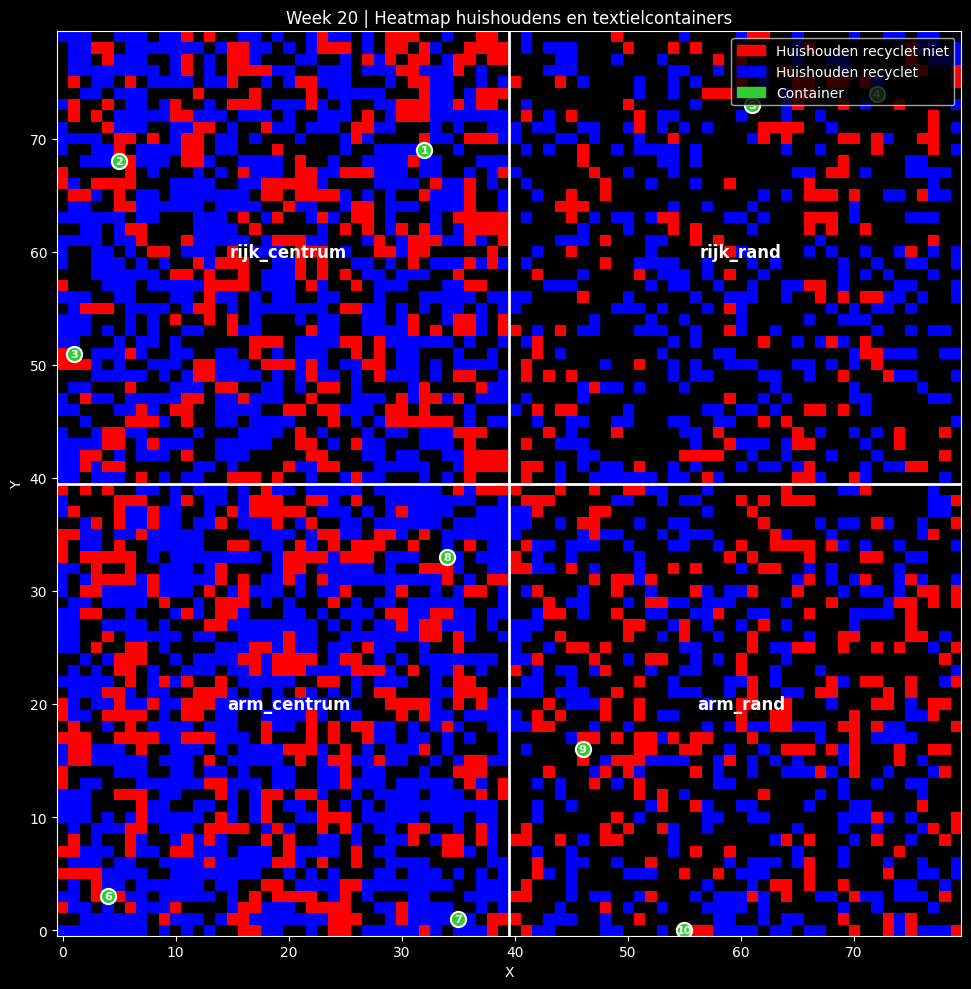

BASE CASE
------------------------------------------------------------
Aantal containers totaal: 10
Huishoudens per container: 320.00
Totaal aangeboden textiel: 13529.61 kg
Totaal gerecycled textiel: 8941.20 kg
Percentage gerecycled: 66.09%
Niet gerecycled door capaciteit: 0.00 kg
Huishoudens die recyclen aan einde: 66.34%

VERGELIJKING SCENARIO'S
------------------------------------------------------------------------------------------------------------------------
       scenario  campagne_intensiteit  container_factor  aantal_containers_totaal  huishoudens_per_container  totaal_aangeboden_kg  totaal_gerecycled_kg  percentage_gerecycled  verschil_pctpunt_tov_base  niet_gerecycled_door_capaciteit_kg  verschil_capaciteit_kg_tov_base  percentage_huishoudens_dat_recyclet_eind  verschil_recyclers_pctpunt_tov_base
      base_case                   1.0               1.0                        10                     320.00              13529.61               8941.20                  66.09   

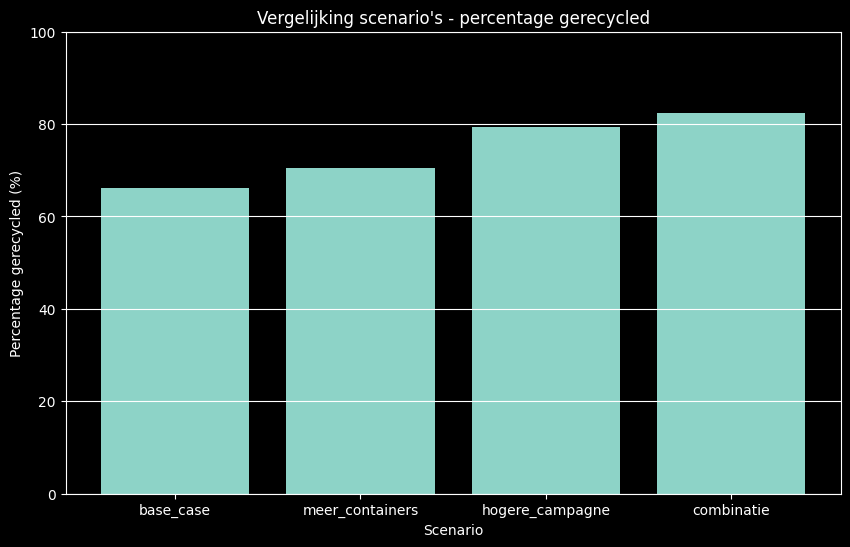

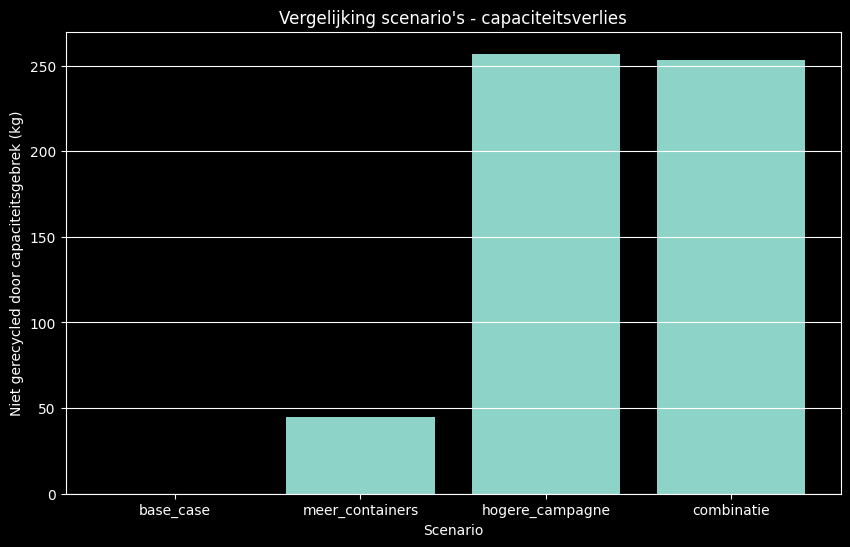

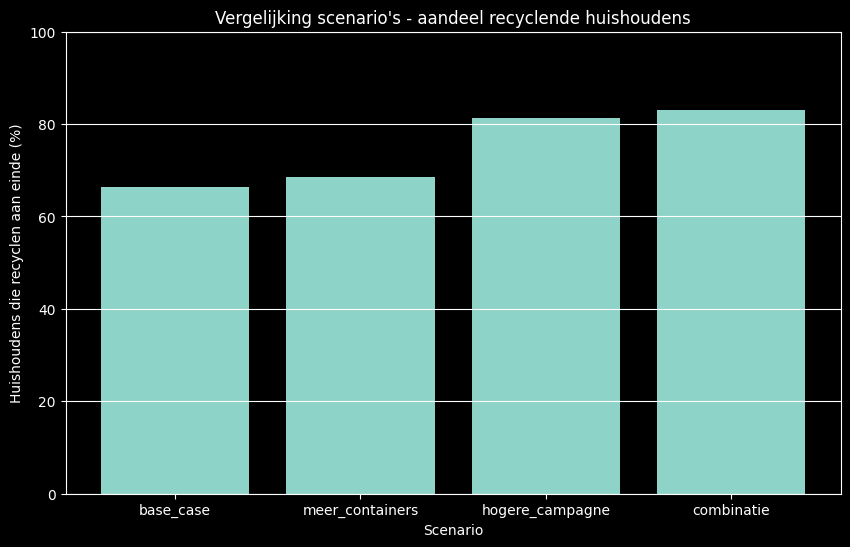

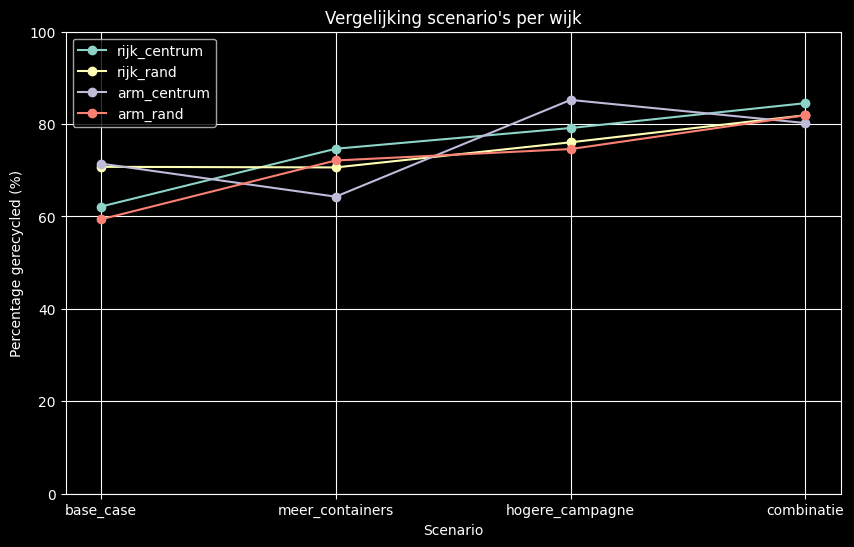

In [4]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mesa import Model, Agent
from mesa.space import MultiGrid



class Huishouden(Agent):


    def __init__(self, unique_id, model, wijk=None, wijk_inkomen_profiel=None, wijk_dichtheid=None):
        super().__init__(unique_id, model)

        self.wijk = wijk
        self.wijk_inkomen_profiel = wijk_inkomen_profiel
        self.wijk_dichtheid = wijk_dichtheid

        # Basis recyclewaarde
        self.basis_recyclewaarde = min(1, max(0, self.model.random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde

        # Sociale invloed
        self.sociale_gevoeligheid = 0

        # Gedrag
        self.recyclegedrag = False
        self.status = "recyclet_niet"

        # Opleidingsniveau
        self.opleidingsniveau = self.model.random.choices(
            ["laag", "midden", "hoog"],
            weights=[0.262, 0.372, 0.366]
        )[0]

        # Inkomen wijkafhankelijk
        if self.wijk_inkomen_profiel == "hoog":
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.05, 0.35, 0.60]
            )[0]
        elif self.wijk_inkomen_profiel == "laag":
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.45, 0.40, 0.15]
            )[0]
        else:
            self.inkomen = self.model.random.choices(
                ["laag", "midden", "hoog"],
                weights=[0.140, 0.556, 0.304]
            )[0]

        # Volgzaamheid richting overheid/campagne
        self.volgzaamheid_overheid = self.model.random.choices(
            ["belangrijk", "neutraal", "onbelangrijk"],
            weights=[0.847, 0.113, 0.04]
        )[0]

        # Huishoudgrootte
        self.huishoudgrootte = self.model.random.choices(
            [1, 2, 3, 4, 5],
            weights=[55, 26, 9, 7, 3]
        )[0]

        # Textielafval
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4

        # Correctie afvalproductie op basis van inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.6
        elif self.inkomen == "midden":
            self.textielafval_per_tijdstap *= 1.0
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.7

        self.opgespaard_textielafval = 0

        # Weggooifrequentie
        self.weggooifrequentie = max(1, round(self.model.random.normalvariate(20, 15)))
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Afstand
        self.afstand = None

        # Totalen
        self.totaal_opgeslagen = 0
        self.totaal_gerecycled = 0

    def update_recyclegedrag(self):
        # Start vanaf basis
        self.recyclewaarde = self.basis_recyclewaarde

        # Buurinvloed
        aantal_buren, buurinvloed = self.model.bereken_buurinvloed(self)
        self.sociale_gevoeligheid = aantal_buren
        self.recyclewaarde += buurinvloed

        # Dichtstbijzijnde container
        _, afstand = self.model.dichtstbijzijnde_container(self)
        self.afstand = afstand

        # Afstandseffect
        max_afstand = (self.model.grid.width - 1) + (self.model.grid.height - 1)
        rel_afstand = afstand / max_afstand if max_afstand > 0 else 0

        if rel_afstand <= 0.2:
            self.recyclewaarde += 0.05
        elif rel_afstand <= 0.4:
            self.recyclewaarde += 0.00
        elif rel_afstand <= 0.6:
            self.recyclewaarde -= 0.05
        else:
            self.recyclewaarde -= 0.10

        # Inkomenseffect
        if self.inkomen == "hoog":
            self.recyclewaarde -= 0.01
        elif self.inkomen == "laag":
            self.recyclewaarde -= 0.03

        # Opleidingsniveau-effect
        if self.opleidingsniveau == "hoog":
            self.recyclewaarde += 0.06
        elif self.opleidingsniveau == "midden":
            self.recyclewaarde -= 0.04
        elif self.opleidingsniveau == "laag":
            self.recyclewaarde -= 0.06

        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Campagne-invloed
        campagne_invloed = 0
        if self.volgzaamheid_overheid == "belangrijk":
            campagne_invloed = self.model.campagne_intensiteit * 0.05
        elif self.volgzaamheid_overheid == "neutraal":
            campagne_invloed = self.model.campagne_intensiteit * 0.03
        elif self.volgzaamheid_overheid == "onbelangrijk":
            campagne_invloed = self.model.campagne_intensiteit * 0.01

        self.recyclewaarde += campagne_invloed
        self.recyclewaarde = min(1, max(0, self.recyclewaarde))

        # Drempel
        self.recyclegedrag = self.recyclewaarde >= self.model.drempel
        self.status = "recyclet" if self.recyclegedrag else "recyclet_niet"

    def produceer_textiel(self):
        self.opgespaard_textielafval += self.textielafval_per_tijdstap
        self.totaal_opgeslagen += self.textielafval_per_tijdstap

        self.model.geproduceerd_deze_stap += self.textielafval_per_tijdstap
        self.model.wijk_resultaten[self.wijk]["geproduceerd_deze_stap"] += self.textielafval_per_tijdstap

    def probeer_textiel_weg_te_brengen(self):
        if self.weken_tot_weggooien <= 0:
            aangeboden_hoeveelheid = self.opgespaard_textielafval

            self.model.aangeboden_deze_stap += aangeboden_hoeveelheid
            self.model.wijk_resultaten[self.wijk]["aangeboden_deze_stap"] += aangeboden_hoeveelheid

            if self.recyclegedrag:
                container, _ = self.model.dichtstbijzijnde_container(self)

                ruimte_over = max(0, container.capaciteit - container.vulgraad)
                hoeveelheid_te_recyclen = min(ruimte_over, aangeboden_hoeveelheid)
                hoeveelheid_niet_gerecycled_door_capaciteit = aangeboden_hoeveelheid - hoeveelheid_te_recyclen

                container.vulgraad += hoeveelheid_te_recyclen
                container.totaal_ingezameld += hoeveelheid_te_recyclen

                self.totaal_gerecycled += hoeveelheid_te_recyclen
                self.model.gerecycled_deze_stap += hoeveelheid_te_recyclen
                self.model.niet_gerecycled_door_capaciteit_deze_stap += hoeveelheid_niet_gerecycled_door_capaciteit

                self.model.wijk_resultaten[self.wijk]["gerecycled_deze_stap"] += hoeveelheid_te_recyclen
                self.model.wijk_resultaten[self.wijk][
                    "niet_gerecycled_door_capaciteit_deze_stap"] += hoeveelheid_niet_gerecycled_door_capaciteit

                # Per huishoudgrootte
                self.model.gerecycled_per_huishoudgrootte[self.huishoudgrootte] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid

                # Per inkomen
                self.model.gerecycled_per_huishoudinkomen[self.inkomen] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid

                # Per opleidingsniveau
                self.model.gerecycled_per_opleidingsniveau[self.opleidingsniveau] += hoeveelheid_te_recyclen
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            else:
                self.model.aangeboden_per_huishoudgrootte[self.huishoudgrootte] += aangeboden_hoeveelheid
                self.model.aangeboden_per_huishoudinkomen[self.inkomen] += aangeboden_hoeveelheid
                self.model.aangeboden_per_opleidingsniveau[self.opleidingsniveau] += aangeboden_hoeveelheid

            self.opgespaard_textielafval = 0
            self.weken_tot_weggooien = self.weggooifrequentie

    def step(self):
        self.produceer_textiel()
        self.weken_tot_weggooien -= 4
        self.update_recyclegedrag()
        self.probeer_textiel_weg_te_brengen()



class Container(Agent):


    def __init__(self, unique_id, model, container_nummer=None):
        super().__init__(unique_id, model)
        self.container_nummer = container_nummer
        self.capaciteit = 750
        self.vulgraad = 0
        self.totaal_ingezameld = 0
        self.ledigingsfrequentie = 8

    def ledigen(self):
        self.vulgraad = 0


class Stad(Model):

#we gaan nu kijken naar hoeveel containers er worden neergezet tenn opzichte van eerst
    def __init__(self, width=80, height=80, campagne_intensiteit=1.0, container_factor=1.0, seed=42):
        super().__init__()

        self.random.seed(seed)

        self.grid = MultiGrid(width, height, torus=False)
        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5
        self.campagne_intensiteit = campagne_intensiteit
        self.container_factor = container_factor

        # Wijken
        self.wijken = {
            "rijk_centrum": {
                "inkomen_profiel": "hoog",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1000,
                "aantal_containers_basis": 3
            },
            "rijk_rand": {
                "inkomen_profiel": "hoog",
                "dichtheid": "laag",
                "aantal_huishoudens": 500,
                "aantal_containers_basis": 2
            },
            "arm_centrum": {
                "inkomen_profiel": "laag",
                "dichtheid": "hoog",
                "aantal_huishoudens": 1100,
                "aantal_containers_basis": 3
            },
            "arm_rand": {
                "inkomen_profiel": "laag",
                "dichtheid": "laag",
                "aantal_huishoudens": 600,
                "aantal_containers_basis": 2
            }
        }

        # de aantal containers word dus aangepast aan de hand van het beleid wat we aan het uitvoeren zijn.
        for wijknaam in self.wijken:
            basis = self.wijken[wijknaam]["aantal_containers_basis"]
            nieuw_aantal = max(1, int(round(basis * self.container_factor)))
            self.wijken[wijknaam]["aantal_containers"] = nieuw_aantal

        # Stapvariabelen
        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        # Tijdsreeksen
        self.geschiedenis_weken = [0]
        self.geproduceerd_per_stap = [0]
        self.aangeboden_per_stap = [0]
        self.gerecycled_per_stap = [0]
        self.niet_gerecycled_door_capaciteit_per_stap = [0]
        self.percentage_gerecycled_van_aangeboden_per_stap = [0]
        self.percentage_huishoudens_dat_recyclet = [0]

        self.geschiedenis_weken_containers = [0]
        self.geschiedenis_container_vulgraden = []
        self.geschiedenis_container_totaal_ingezameld = []

        # Wijkresultaten
        self.wijk_resultaten = {}
        for wijknaam in self.wijken.keys():
            self.wijk_resultaten[wijknaam] = {
                "geproduceerd_deze_stap": 0,
                "aangeboden_deze_stap": 0,
                "gerecycled_deze_stap": 0,
                "niet_gerecycled_door_capaciteit_deze_stap": 0,
                "geproduceerd_per_stap": [0],
                "aangeboden_per_stap": [0],
                "gerecycled_per_stap": [0],
                "niet_gerecycled_door_capaciteit_per_stap": [0],
                "percentage_gerecycled_van_aangeboden_per_stap": [0],
                "percentage_huishoudens_dat_recyclet": [0],
                "container_vulgraden": [],
                "container_totaal_ingezameld": []
            }

        # Uitkomsten per categorie
        self.aangeboden_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudgrootte = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
        self.gerecycled_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_huishoudinkomen = {"laag": 0, "midden": 0, "hoog": 0}
        self.aangeboden_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}
        self.gerecycled_per_opleidingsniveau = {"laag": 0, "midden": 0, "hoog": 0}

        midden_x = width // 2
        midden_y = height // 2

        wijk_posities = {
            "rijk_centrum": [(x, y) for x in range(0, midden_x) for y in range(midden_y, height)],
            "rijk_rand": [(x, y) for x in range(midden_x, width) for y in range(midden_y, height)],
            "arm_centrum": [(x, y) for x in range(0, midden_x) for y in range(0, midden_y)],
            "arm_rand": [(x, y) for x in range(midden_x, width) for y in range(0, midden_y)],
        }

        for wijknaam, info in self.wijken.items():
            mogelijke_posities = wijk_posities[wijknaam][:]
            nodig = info["aantal_huishoudens"] + info["aantal_containers"]

            if nodig > len(mogelijke_posities):
                raise ValueError(f"Te veel agents voor wijk {wijknaam}")

            gekozen_posities = self.random.sample(mogelijke_posities, nodig)
            container_posities = gekozen_posities[:info["aantal_containers"]]
            huishouden_posities = gekozen_posities[info["aantal_containers"]:]

            for pos in container_posities:
                c = Container(self.next_id(), self, container_nummer=len(self.containers) + 1)
                c.wijk = wijknaam
                self.grid.place_agent(c, pos)
                self.containers.append(c)

            for pos in huishouden_posities:
                h = Huishouden(
                    self.next_id(),
                    self,
                    wijk=wijknaam,
                    wijk_inkomen_profiel=info["inkomen_profiel"],
                    wijk_dichtheid=info["dichtheid"]
                )
                self.grid.place_agent(h, pos)
                self.huishoudens.append(h)

        for huishouden in self.huishoudens:
            huishouden.update_recyclegedrag()

        # Startwaarden containerhistorie
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])

        for wijknaam in self.wijken.keys():
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            self.wijk_resultaten[wijknaam]["container_vulgraden"].append(
                [container.vulgraad for container in wijk_containers]
            )
            self.wijk_resultaten[wijknaam]["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers]
            )

    def next_id(self):
        self.id += 1
        return self.id

    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def dichtstbijzijnde_container(self, huishouden):
        containers_in_eigen_wijk = [c for c in self.containers if c.wijk == huishouden.wijk]
        te_controleren_containers = containers_in_eigen_wijk if containers_in_eigen_wijk else self.containers

        beste_container = None
        kleinste_afstand = float("inf")

        for container in te_controleren_containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)
            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden) and agent.wijk == huishouden.wijk:
                        aantal_buren += 1
                        buurinvloed += 0.05 if agent.recyclegedrag else -0.05

        return aantal_buren, buurinvloed

    def verzamel_resultaten(self):
        self.geschiedenis_weken.append(self.week)
        self.geproduceerd_per_stap.append(self.geproduceerd_deze_stap)
        self.aangeboden_per_stap.append(self.aangeboden_deze_stap)
        self.gerecycled_per_stap.append(self.gerecycled_deze_stap)
        self.niet_gerecycled_door_capaciteit_per_stap.append(self.niet_gerecycled_door_capaciteit_deze_stap)

        percentage = (
                             self.gerecycled_deze_stap / self.aangeboden_deze_stap) * 100 if self.aangeboden_deze_stap > 0 else 0
        self.percentage_gerecycled_van_aangeboden_per_stap.append(percentage)

        aantal_recyclers = sum(1 for h in self.huishoudens if h.recyclegedrag)
        percentage_recyclers = (aantal_recyclers / len(self.huishoudens)) * 100 if self.huishoudens else 0
        self.percentage_huishoudens_dat_recyclet.append(percentage_recyclers)

        self.geschiedenis_weken_containers.append(self.week)
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])

        for wijknaam in self.wijken.keys():
            wijk_data = self.wijk_resultaten[wijknaam]

            wijk_data["geproduceerd_per_stap"].append(wijk_data["geproduceerd_deze_stap"])
            wijk_data["aangeboden_per_stap"].append(wijk_data["aangeboden_deze_stap"])
            wijk_data["gerecycled_per_stap"].append(wijk_data["gerecycled_deze_stap"])
            wijk_data["niet_gerecycled_door_capaciteit_per_stap"].append(
                wijk_data["niet_gerecycled_door_capaciteit_deze_stap"])

            percentage_wijk = (
                (wijk_data["gerecycled_deze_stap"] / wijk_data["aangeboden_deze_stap"]) * 100
                if wijk_data["aangeboden_deze_stap"] > 0 else 0
            )
            wijk_data["percentage_gerecycled_van_aangeboden_per_stap"].append(percentage_wijk)

            wijk_huishoudens = [h for h in self.huishoudens if h.wijk == wijknaam]
            aantal_recyclers_wijk = sum(1 for h in wijk_huishoudens if h.recyclegedrag)
            percentage_recyclers_wijk = (aantal_recyclers_wijk / len(wijk_huishoudens)) * 100 if wijk_huishoudens else 0
            wijk_data["percentage_huishoudens_dat_recyclet"].append(percentage_recyclers_wijk)

            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            wijk_data["container_vulgraden"].append([container.vulgraad for container in wijk_containers])
            wijk_data["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers])

    def registreer_lediging_in_containergrafieken(self):
        self.geschiedenis_weken_containers.append(self.week)
        self.geschiedenis_container_vulgraden.append([container.vulgraad for container in self.containers])
        self.geschiedenis_container_totaal_ingezameld.append(
            [container.totaal_ingezameld for container in self.containers])

        for wijknaam in self.wijken.keys():
            wijk_containers = [c for c in self.containers if c.wijk == wijknaam]
            self.wijk_resultaten[wijknaam]["container_vulgraden"].append(
                [container.vulgraad for container in wijk_containers]
            )
            self.wijk_resultaten[wijknaam]["container_totaal_ingezameld"].append(
                [container.totaal_ingezameld for container in wijk_containers]
            )

    def step(self):
        self.week += 4

        self.geproduceerd_deze_stap = 0
        self.aangeboden_deze_stap = 0
        self.gerecycled_deze_stap = 0
        self.niet_gerecycled_door_capaciteit_deze_stap = 0

        for wijknaam in self.wijken.keys():
            self.wijk_resultaten[wijknaam]["geproduceerd_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["aangeboden_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["gerecycled_deze_stap"] = 0
            self.wijk_resultaten[wijknaam]["niet_gerecycled_door_capaciteit_deze_stap"] = 0

        for huishouden in self.huishoudens:
            huishouden.step()

        self.verzamel_resultaten()

        if self.containers and self.week % self.containers[0].ledigingsfrequentie == 0:
            for container in self.containers:
                container.ledigen()
            self.registreer_lediging_in_containergrafieken()


    def visualiseer_heatmap(self):
        heatmap = np.zeros((self.grid.height, self.grid.width))

        for h in self.huishoudens:
            x, y = h.pos
            heatmap[y, x] = 2 if h.recyclegedrag else 1

        for c in self.containers:
            x, y = c.pos
            heatmap[y, x] = 3

        cmap = ListedColormap(["black", "red", "blue", "limegreen"])

        plt.figure(figsize=(10, 10))
        plt.imshow(heatmap, origin="lower", cmap=cmap, interpolation="nearest")
        plt.title(f"Week {self.week} | Heatmap huishoudens en textielcontainers")
        plt.xlabel("X")
        plt.ylabel("Y")

        midden_x = self.grid.width // 2
        midden_y = self.grid.height // 2

        plt.axvline(midden_x - 0.5, color="white", linewidth=2)
        plt.axhline(midden_y - 0.5, color="white", linewidth=2)

        plt.text(midden_x / 2, midden_y + (self.grid.height - midden_y) / 2, "rijk_centrum",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x + (self.grid.width - midden_x) / 2, midden_y + (self.grid.height - midden_y) / 2, "rijk_rand",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x / 2, midden_y / 2, "arm_centrum",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")
        plt.text(midden_x + (self.grid.width - midden_x) / 2, midden_y / 2, "arm_rand",
                 color="white", ha="center", va="center", fontsize=12, weight="bold")

        for c in self.containers:
            x, y = c.pos
            plt.scatter(x, y, s=120, c="limegreen", edgecolors="white", linewidths=1.5)
            plt.text(
                x, y, str(c.container_nummer),
                color="white",
                ha="center",
                va="center",
                fontsize=8,
                weight="bold"
            )

        import matplotlib.patches as mpatches
        legend_items = [
            mpatches.Patch(color="red", label="Huishouden recyclet niet"),
            mpatches.Patch(color="blue", label="Huishouden recyclet"),
            mpatches.Patch(color="limegreen", label="Container")
        ]
        plt.legend(handles=legend_items, loc="upper right")
        plt.tight_layout()
        plt.show()


#run het basis model
def run_scenario(
        scenario_naam="basis",
        campagne_intensiteit=1.0,
        container_factor=1.0,
        stappen=5,
        seed=42,
        toon_heatmap=False
):
    model = Stad(
        width=80,
        height=80,
        campagne_intensiteit=campagne_intensiteit,
        container_factor=container_factor,
        seed=seed
    )

    for _ in range(stappen):
        model.step()

    totaal_geproduceerd = sum(model.geproduceerd_per_stap)
    totaal_aangeboden = sum(model.aangeboden_per_stap)
    totaal_gerecycled = sum(model.gerecycled_per_stap)
    totaal_niet_capaciteit = sum(model.niet_gerecycled_door_capaciteit_per_stap)

    percentage_gerecycled = (
        (totaal_gerecycled / totaal_aangeboden) * 100
        if totaal_aangeboden > 0 else 0
    )

    percentage_recyclers_eind = model.percentage_huishoudens_dat_recyclet[-1]

    aantal_containers_totaal = len(model.containers)
    huishoudens_per_container = len(model.huishoudens) / aantal_containers_totaal

    wijk_percentages = {}
    for wijknaam in model.wijken.keys():
        wijk_data = model.wijk_resultaten[wijknaam]
        wijk_aangeboden = sum(wijk_data["aangeboden_per_stap"])
        wijk_gerecycled = sum(wijk_data["gerecycled_per_stap"])
        wijk_percentage = (wijk_gerecycled / wijk_aangeboden) * 100 if wijk_aangeboden > 0 else 0
        wijk_percentages[wijknaam] = wijk_percentage

    if toon_heatmap:
        model.visualiseer_heatmap()

    return {
        "scenario": scenario_naam,
        "campagne_intensiteit": campagne_intensiteit,
        "container_factor": container_factor,
        "aantal_containers_totaal": aantal_containers_totaal,
        "huishoudens_per_container": huishoudens_per_container,
        "totaal_geproduceerd_kg": totaal_geproduceerd,
        "totaal_aangeboden_kg": totaal_aangeboden,
        "totaal_gerecycled_kg": totaal_gerecycled,
        "percentage_gerecycled": percentage_gerecycled,
        "niet_gerecycled_door_capaciteit_kg": totaal_niet_capaciteit,
        "percentage_huishoudens_dat_recyclet_eind": percentage_recyclers_eind,
        "pct_rijk_centrum": wijk_percentages["rijk_centrum"],
        "pct_rijk_rand": wijk_percentages["rijk_rand"],
        "pct_arm_centrum": wijk_percentages["arm_centrum"],
        "pct_arm_rand": wijk_percentages["arm_rand"],
        "model": model
    }

#dit zijn de verschillende scenarios die we gaan runnen
def vergelijk_scenarios(stappen=5, seed=42):
    scenario_lijst = [
        {"scenario_naam": "base_case", "campagne_intensiteit": 1.0, "container_factor": 1.0},
        {"scenario_naam": "meer_containers", "campagne_intensiteit": 1.0, "container_factor": 1.5},
        {"scenario_naam": "hogere_campagne", "campagne_intensiteit": 2.0, "container_factor": 1.0},
        {"scenario_naam": "combinatie", "campagne_intensiteit": 2.0, "container_factor": 1.5},
    ]

    resultaten = []
    modellen = {}

    for s in scenario_lijst:
        uitkomst = run_scenario(
            scenario_naam=s["scenario_naam"],
            campagne_intensiteit=s["campagne_intensiteit"],
            container_factor=s["container_factor"],
            stappen=stappen,
            seed=seed,
            toon_heatmap=False
        )
        modellen[s["scenario_naam"]] = uitkomst["model"]

        resultaten.append({
            "scenario": uitkomst["scenario"],
            "campagne_intensiteit": uitkomst["campagne_intensiteit"],
            "container_factor": uitkomst["container_factor"],
            "aantal_containers_totaal": uitkomst["aantal_containers_totaal"],
            "huishoudens_per_container": uitkomst["huishoudens_per_container"],
            "totaal_aangeboden_kg": uitkomst["totaal_aangeboden_kg"],
            "totaal_gerecycled_kg": uitkomst["totaal_gerecycled_kg"],
            "percentage_gerecycled": uitkomst["percentage_gerecycled"],
            "niet_gerecycled_door_capaciteit_kg": uitkomst["niet_gerecycled_door_capaciteit_kg"],
            "percentage_huishoudens_dat_recyclet_eind": uitkomst["percentage_huishoudens_dat_recyclet_eind"],
            "pct_rijk_centrum": uitkomst["pct_rijk_centrum"],
            "pct_rijk_rand": uitkomst["pct_rijk_rand"],
            "pct_arm_centrum": uitkomst["pct_arm_centrum"],
            "pct_arm_rand": uitkomst["pct_arm_rand"],
        })

    df = pd.DataFrame(resultaten)

    basis_pct = df.loc[df["scenario"] == "base_case", "percentage_gerecycled"].iloc[0]
    basis_cap = df.loc[df["scenario"] == "base_case", "niet_gerecycled_door_capaciteit_kg"].iloc[0]
    basis_recyclers = df.loc[df["scenario"] == "base_case", "percentage_huishoudens_dat_recyclet_eind"].iloc[0]

    df["verschil_pctpunt_tov_base"] = df["percentage_gerecycled"] - basis_pct
    df["verschil_capaciteit_kg_tov_base"] = df["niet_gerecycled_door_capaciteit_kg"] - basis_cap
    df["verschil_recyclers_pctpunt_tov_base"] = df["percentage_huishoudens_dat_recyclet_eind"] - basis_recyclers

    return df, modellen


# ============================================================
# GRAFIEKEN VOOR VERSLAG
# ============================================================
def plot_vergelijking_recyclingpercentage(df):
    plt.figure(figsize=(10, 6))
    plt.bar(df["scenario"], df["percentage_gerecycled"])
    plt.xlabel("Scenario")
    plt.ylabel("Percentage gerecycled (%)")
    plt.title("Vergelijking scenario's - percentage gerecycled")
    plt.ylim(0, 100)
    plt.grid(True, axis="y")
    plt.show()


def plot_vergelijking_capaciteitsverlies(df):
    plt.figure(figsize=(10, 6))
    plt.bar(df["scenario"], df["niet_gerecycled_door_capaciteit_kg"])
    plt.xlabel("Scenario")
    plt.ylabel("Niet gerecycled door capaciteitsgebrek (kg)")
    plt.title("Vergelijking scenario's - capaciteitsverlies")
    plt.grid(True, axis="y")
    plt.show()


def plot_vergelijking_recyclers(df):
    plt.figure(figsize=(10, 6))
    plt.bar(df["scenario"], df["percentage_huishoudens_dat_recyclet_eind"])
    plt.xlabel("Scenario")
    plt.ylabel("Huishoudens die recyclen aan einde (%)")
    plt.title("Vergelijking scenario's - aandeel recyclende huishoudens")
    plt.ylim(0, 100)
    plt.grid(True, axis="y")
    plt.show()


def plot_vergelijking_per_wijk(df):
    plt.figure(figsize=(10, 6))
    plt.plot(df["scenario"], df["pct_rijk_centrum"], marker="o", label="rijk_centrum")
    plt.plot(df["scenario"], df["pct_rijk_rand"], marker="o", label="rijk_rand")
    plt.plot(df["scenario"], df["pct_arm_centrum"], marker="o", label="arm_centrum")
    plt.plot(df["scenario"], df["pct_arm_rand"], marker="o", label="arm_rand")
    plt.xlabel("Scenario")
    plt.ylabel("Percentage gerecycled (%)")
    plt.title("Vergelijking scenario's per wijk")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# UITVOER BASE CASE + BELEIDSVERGELIJKING
# ============================================================

# 1. Draai alleen de base case
base_case = run_scenario(
    scenario_naam="base_case",
    campagne_intensiteit=1.0,
    container_factor=1.0,
    stappen=5,
    seed=42,
    toon_heatmap=True
)

print("BASE CASE")
print("-" * 60)
print(f"Aantal containers totaal: {base_case['aantal_containers_totaal']}")
print(f"Huishoudens per container: {base_case['huishoudens_per_container']:.2f}")
print(f"Totaal aangeboden textiel: {base_case['totaal_aangeboden_kg']:.2f} kg")
print(f"Totaal gerecycled textiel: {base_case['totaal_gerecycled_kg']:.2f} kg")
print(f"Percentage gerecycled: {base_case['percentage_gerecycled']:.2f}%")
print(f"Niet gerecycled door capaciteit: {base_case['niet_gerecycled_door_capaciteit_kg']:.2f} kg")
print(f"Huishoudens die recyclen aan einde: {base_case['percentage_huishoudens_dat_recyclet_eind']:.2f}%")

# 2. Vergelijk alle scenario's
df_vergelijking, modellen = vergelijk_scenarios(stappen=5, seed=42)

print("\nVERGELIJKING SCENARIO'S")
print("-" * 120)
print(df_vergelijking[[
    "scenario",
    "campagne_intensiteit",
    "container_factor",
    "aantal_containers_totaal",
    "huishoudens_per_container",
    "totaal_aangeboden_kg",
    "totaal_gerecycled_kg",
    "percentage_gerecycled",
    "verschil_pctpunt_tov_base",
    "niet_gerecycled_door_capaciteit_kg",
    "verschil_capaciteit_kg_tov_base",
    "percentage_huishoudens_dat_recyclet_eind",
    "verschil_recyclers_pctpunt_tov_base"
]].round(2).to_string(index=False))

print("\nPERCENTAGES PER WIJK")
print("-" * 120)
print(df_vergelijking[[
    "scenario",
    "pct_rijk_centrum",
    "pct_rijk_rand",
    "pct_arm_centrum",
    "pct_arm_rand"
]].round(2).to_string(index=False))

# 3. Grafieken
plot_vergelijking_recyclingpercentage(df_vergelijking)
plot_vergelijking_capaciteitsverlies(df_vergelijking)
plot_vergelijking_recyclers(df_vergelijking)
plot_vergelijking_per_wijk(df_vergelijking)